# Fine-Tune Multi-Modal (image+text) Gemini model for Visual Q+A


Lynne Grewe, Professor CS, CSUEB, iLab

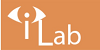


This Colab is an **end-to-end pipeline for fine-tuning a multimodal Gemini model (image + text) on a Visual Question Answering task using Vertex AI**. It installs the required libraries, authenticates to your Google Cloud project, lets you **pick a Hugging Face multimodal Q\&A dataset**, converts that data into **Gemini Supervised Fine-Tuning (SFT) JSONL**, uploads it to **Cloud Storage**, **launches a Vertex AI SFT job** on a chosen Gemini base model (e.g., `gemini-2.5-flash`), and then **tests and compares** the tuned model against the original base model. The notebook also includes quick ways to **monitor the job**, **fetch the tuned endpoint**, and **run side-by-side evaluations**.

### <font color=red>[Prequisite Setup Instructions Manual](https://docs.google.com/document/d/1cxvwYJ0x8Dwqubbyy1Pl4g4OLtw_sDMnUaoc9gKs4As)</red>

### At a glance — steps in the notebook

1. **Install dependencies**
   Installs `google-genai`, `google-cloud-aiplatform/vertexai`, `google-cloud-storage`, `datasets`, and utilities.

2. **Authenticate & configure**
   Reads your **`GOOGLE_CLOUD_PROJECT`**, **`GOOGLE_DEFAULT_REGION`**, and **`GOOGLE_DEFAULT_BUCKET`**; creates/validates the Cloud Storage bucket; initializes Vertex AI.

3. **Choose base model & tuning knobs**
   Pick a Gemini base model (e.g., `gemini-2.5-flash`, `gemini-2.5-pro`) and set tuning params like **epochs**, **learning\_rate\_multiplier**, and **adapter size**.

4. **Select a Hugging Face multimodal Q\&A dataset**
   Load a public HF dataset suitable for VQA; preview examples and **choose split sizes** for train/validation/test.

5. **Build SFT JSONL & upload to GCS**
   Convert samples into the **Gemini SFT JSONL** format (each line has `contents` with `fileData` for the image and user question, plus the model’s target answer). Upload the train/validation JSONL files to your bucket. (Notebook includes a quick bucket check.)

6. **Launch the Supervised Fine-Tuning job**
   Starts a Vertex AI **SupervisedTuningJob** pointing at your JSONL files and selected model/params; prints the **Console link** to track progress.

7. **Monitor job status** *(optional poll)*
   List tuning jobs, inspect the one you launched, and optionally **poll** until completion.

8. **Test the tuned model**

   * **Option A:** Resolve and call the **tuned endpoint** directly and run a few predictions.
   * **Option B:** Use the **Tuning Job ID** → get the model ID and run quick inference.
   * **Option C:** Try the **Vertex AI “Test” UI** (upload an image, type a prompt).

9. **Compare tuned vs. base**
   Run both models on a shared (validation/test) set and **display results side-by-side** in a table to gauge improvement.

### Inputs you provide

* GCP project, region, and GCS bucket.
* Choice of **Gemini base model** and **tuning params**.
* Choice of **multimodal dataset** and **split sizes**.

### Outputs you get

* **Train/validation JSONL** files in your bucket.
* A **Vertex AI tuning job** with Console link.
* A **tuned model endpoint/model ID** for inference.
* **Evaluation summaries** comparing tuned vs. base Gemini.






# STEP 1: Installs (HF datasets + Vertex AI libs)


* **datasets** is the open-source **Hugging Face library **for finding, loading, and preprocessing datasets (text, vision, audio, multimodal). It gives you fast, memory-efficient Dataset objects (Arrow/Parquet under the hood) with handy ops like map, filter, shuffle, and automatic caching.*

In [ ]:
#@title Install libraries (pin versions so no conflicts like script-based HF datasets load cleanly)
# --- Clean out known conflict sources (safe to skip if not present)
!pip -q uninstall -y vertexai gcsfs fsspec google-adk

# --- Pass A: HF + datasets stack (lets `datasets` pick compatible fsspec)
!pip -q install -U \
  "datasets==2.19.2" \
  "huggingface_hub>=0.24.0" \
  "tqdm>=4.66.0" \
  "Pillow>=10.4.0" \
  "ipywidgets>=8.1.2"

# --- Pass B: Google libs (no separate `vertexai` package needed)
!pip -q install -U \
  "google-genai>=0.3.0" \
  "google-cloud-aiplatform>=1.71,<2" \
  "google-cloud-storage>=2.17.0"

import datasets, fsspec, google.cloud.aiplatform as aiplatform
import vertexai  # provided by google-cloud-aiplatform
print("datasets:", datasets.__version__)
print("fsspec:", fsspec.__version__)
print("aiplatform:", aiplatform.__version__)
print("vertexai module OK")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.24.0 requires gcsfs!=2025.5.0,>=2023.3.0, which is not installed.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.7/236.7 kB 16.9 MB/s eta 0:00:00
datasets: 2.19.2
fsspec: 2024.3.1
aiplatform: 1.120.0
vertexai module OK


# STEP 2: Auth + project/region + buckets

### 1. Authentication done through login prompt
* → choose your Google account (owner of project) → approve the requested scopes (usually cloud-platform).

*  Owner is a basic, all-powerful role (includes create/read/write on Storage, starting Vertex AI jobs, etc.). You don’t need to add the other roles for your user.

### 2. Requires secrets to be stored

 🔑 Explanation of secrets:
 - GOOGLE_CLOUD_PROJECT: The ID of your Google Cloud project.#   You can find this in the Google Cloud Console at the very top bar,
   or under "Home > Project Info". Example: "my-gcp-project-1234".

 - GOOGLE_DEFAULT_REGION: The region where Vertex AI jobs and the storage bucket will live.
   Common choice is "us-central1". Keep it consistent between your bucket and Vertex AI jobs.

 - GOOGLE_DEFAULT_BUCKET: The name of the Cloud Storage bucket you want to use.
   must be  unique Bucket name.
 **IMPORTANT: The value must be unique.  Consider using my-gemini-sft-bucket-YOURFISTNAME-YOURLASTNAME-CITYyouWorkIn** Example:
   gs://my-gemini-bucket-Lynne-Grewe-Hayward

### 3. Generated values
 📂  GCS_PREFIX:
 - This is an auto-generated "folder-like" prefix inside the bucket.
 - A timestamp is added so each fine-tuning run saves its data in a unique location.

📂 GOOGLE_BUCKET :
 - Set to Google_Default_Bucket
 - must be  unique Bucket name.
 - The notebook will check if this bucket already exists, and create it if it doesn’t.
   You can see all your buckets in the Cloud Console:
   https://console.cloud.google.com/storage/browser



In [ ]:
#@title Authenticate and set project/region/bucket from Colab userdata (no GUI, no bucket modification)

# 🔑 Secrets expected in Colab userdata:
# - GOOGLE_CLOUD_PROJECT: Your Google Cloud project ID (Cloud Console → "Project Info")
# - GOOGLE_DEFAULT_REGION: Region for Vertex AI and storage bucket (e.g., "us-central1")
# - GOOGLE_DEFAULT_BUCKET: The exact GCS bucket to use (will NOT be modified)

# 📂 GCS_PREFIX:
# - A timestamped folder-like prefix for organizing run data within the existing bucket.

# 1) Authenticate Colab with your Google account
from google.colab import auth as colab_auth
colab_auth.authenticate_user()

# 2) Read secrets from Colab userdata
from google.colab import userdata
import datetime

PROJECT_ID = userdata.get('GOOGLE_CLOUD_PROJECT')
REGION = userdata.get('GOOGLE_DEFAULT_REGION') or "us-central1"
GCS_BUCKET = userdata.get('GOOGLE_DEFAULT_BUCKET')

assert PROJECT_ID, "❌ Missing GOOGLE_CLOUD_PROJECT in userdata."
assert GCS_BUCKET, "❌ Missing GOOGLE_DEFAULT_BUCKET in userdata."

# 3) Initialize Vertex AI
import vertexai
vertexai.init(project=PROJECT_ID, location=REGION)

# 4) Create unique prefix for this run
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
GCS_PREFIX = f"multimodal_sft_{timestamp}"

# 5) Helper for building gs:// URIs
def gs_uri(*parts):
    return "gs://" + "/".join([GCS_BUCKET] + [p.strip("/") for p in parts])

# 6) Save globally for reuse
globals()["PROJECT_ID"] = PROJECT_ID
globals()["REGION"] = REGION
globals()["GCS_BUCKET"] = GCS_BUCKET
globals()["GCS_PREFIX"] = GCS_PREFIX
globals()["gs_uri"] = gs_uri

# 7) Print summary
print("✅ Environment initialized")
print("✅ Project:", PROJECT_ID)
print("✅ Region:", REGION)
print("✅ Bucket:", f"gs://{GCS_BUCKET}")
print("📂 Prefix:", GCS_PREFIX)


✅ Environment initialized
✅ Project: demoproject-438016
✅ Region: us-central1
✅ Bucket: gs://my-gemini-sft-bucket
📂 Prefix: multimodal_sft_20251014_185930


# STEP 3: Choose a multimodal base model + "tuning knobs"

**BASE-MODEL**
This is the Gemini model you will fine-tune. Options include:

*   gemini-2.5-flash: Fastest and most cost-efficient multimodal Gemini. Recommended default for visual question answering (VQA) and captioning tasks.
*   gemini-2.5-pro: Larger, more capable model with bigger context window, but slower and more expensive.
*  gemini-2.0-flash: Previous generation multimodal model. Slightly older but still works.
*  gemini-2.0-flash-lite: Smallest and cheapest model, with reduced accuracy.



**EPOCHS**
* The number of times the model sees the entire training dataset.

* Fewer epochs (1–2): Good for pipeline testing or when your dataset is large.

* More epochs (3–5 or more): Helps the model learn better on smaller datasets but can cause overfitting and higher cost.

**ADAPTER_SIZE**
Controls the size of the additional trainable layers during fine-tuning.

* TINY / SMALL: Lower cost, lighter models. May underfit complex tasks.

* MEDIUM / LARGE: More capacity to learn complex patterns, but more expensive to train and deploy.

**LEARNING_RATE_MULTIPLIER**
Scales the default learning rate.

* 1.0: Safe default for most datasets.

* <1.0 (e.g., 0.5): Smaller steps, good for small or noisy datasets. Reduces risk of instability.

* more than 1.0 (e.g., 2.0): Larger steps, may converge faster on large clean datasets, but risks overshooting.

In [ ]:
# STEP 3: Choose base Gemini model + tuning params (with widgets)
import ipywidgets as widgets
from IPython.display import display, clear_output

# Use prior values if they exist, else defaults
_default_base   = globals().get("BASE_MODEL", "gemini-2.5-flash")
_default_epochs = int(globals().get("EPOCHS", 2))
_default_adapt  = str(globals().get("ADAPTER_SIZE", "SMALL"))
_default_lrm    = float(globals().get("LEARNING_RATE_MULTIPLIER", 1.0))

# Adapter size mapping (string -> integer bottleneck size)
_ADAPTER_TO_INT = {"TINY": 1, "SMALL": 4, "MEDIUM": 8, "LARGE": 16}

# Widgets
base_dd = widgets.Dropdown(
    options=["gemini-2.5-flash","gemini-2.5-pro","gemini-2.0-flash","gemini-2.0-flash-lite"],
    value=_default_base,
    description="Base model:",
    layout=widgets.Layout(width="420px"),
)

epochs_in = widgets.IntText(
    value=_default_epochs, description="Epochs:", min=1, step=1, layout=widgets.Layout(width="180px")
)

adapter_dd = widgets.Dropdown(
    options=[("Tiny (1)", "TINY"), ("Small (4)", "SMALL"), ("Medium (8)", "MEDIUM"), ("Large (16)", "LARGE")],
    value=_default_adapt,
    description="Adapter:",
    layout=widgets.Layout(width="220px"),
)

lrm_in = widgets.FloatText(
    value=_default_lrm, description="LR Mult:", layout=widgets.Layout(width="180px")
)

apply_btn = widgets.Button(description="Apply settings", button_style="primary")
out = widgets.Output()

def on_apply(_):
    with out:
        clear_output()
        # Write selections into globals so later cells see them
        globals()["BASE_MODEL"] = base_dd.value
        globals()["EPOCHS"] = int(epochs_in.value)
        globals()["ADAPTER_SIZE"] = adapter_dd.value
        globals()["ADAPTER_SIZE_INT"] = _ADAPTER_TO_INT[adapter_dd.value]  # for APIs needing an int
        globals()["LEARNING_RATE_MULTIPLIER"] = float(lrm_in.value)

        print("✔ Settings applied")
        print("Base model:", BASE_MODEL)
        print("Epochs:", EPOCHS)
        print("Adapter:", ADAPTER_SIZE, "(int:", ADAPTER_SIZE_INT, ")")
        print("LR multiplier:", LEARNING_RATE_MULTIPLIER)

apply_btn.on_click(on_apply)

ui = widgets.VBox([
    base_dd,
    widgets.HBox([epochs_in, adapter_dd, lrm_in]),
    apply_btn,
    out
])

display(ui)


## STEP 3.1 adapter name convert to integer
(should be integer)


* map the user selection of tiny/small/medicum/large to numbers
* Typical choices are small integers like 8, 16, 32, 64 (powers of two are common).
* Higher number more layers more parameters to train --> more time, more cost
* <font color=red>For **cost/time reasons** we are error on slightly lower numbers</font>



In [ ]:
#STEP 3.1 — Map ADAPTER_SIZE to integer (SDK expects 1,4,8,16)
# Accepts either labels ("TINY","SMALL","MEDIUM","LARGE") or integers/strings 1/4/8/16

_ADAPTER_LABEL_TO_INT = {
    "TINY": 1, "SMALL": 4, "MEDIUM": 8, "LARGE": 16,
    "tiny": 1, "small": 4, "medium": 8, "large": 16,
}

def normalize_adapter_size(x):
    if isinstance(x, (int, float)):
        xi = int(x)
        if xi in (1, 4, 8, 16):
            return xi
    if isinstance(x, str):
        x = x.strip()
        if x.isdigit() and int(x) in (1, 4, 8, 16):
            return int(x)
        if x in _ADAPTER_LABEL_TO_INT:
            return _ADAPTER_LABEL_TO_INT[x]
    raise ValueError("Invalid ADAPTER_SIZE. Use one of {1,4,8,16} or labels TINY/SMALL/MEDIUM/LARGE.")

ADAPTER_SIZE_NUM = normalize_adapter_size(ADAPTER_SIZE)
print("✅ Using adapter_size:", ADAPTER_SIZE_NUM)


✅ Using adapter_size: 4


# STEP 4 Select a Hugging Face Multimodal Q+A dataset

uses load_dataset  (rom HuggingFace dataset library)




* Downloads (once) and caches a dataset from the Hugging Face Hub or loads your local files.

* Builds splits (train/validation/test) and returns a Dataset or DatasetDict.

* Infers types (text, labels, Image, Audio, etc.) and exposes them as columns.

* Supports streaming very large datasets, so you don’t have to download everything up front.

In [ ]:
from datasets import load_dataset
import ipywidgets as widgets
from IPython.display import display, clear_output

LABEL_TO_REPO = {
    "Butterflies": "Dasool/butterflies_and_moths_vqa",
    "Book Cover VQA (CONTAINS PEOPLE)": "howard-hou/OCR-VQA",
    "Radiology": "flaviagiammarino/vqa-rad",
    "Gastroinstestinal Endoscopy": "SimulaMet/Kvasir-VQA-x1",
}

dd = widgets.Dropdown(
    options=list(LABEL_TO_REPO.keys()),
    description="Dataset:",
    layout=widgets.Layout(width="600px"),
)

btn = widgets.Button(description="Load dataset", button_style="primary")
out = widgets.Output()

def on_click_load(_):
    label = dd.value
    repo_id = LABEL_TO_REPO[label]
    with out:
        clear_output()
        print(f"Selected label: {label}")
        print(f"Loading dataset: {repo_id} ...")
    globals()["ds"] = load_dataset(repo_id)   #this will produce ds as a global variable of dataset

    # Build a short name from the repo tail and store globally
    globals()["SELECTED_HF_REPO"] = repo_id
    globals()["SELECTED_HF_NAME"] = repo_id.split("/")[-1]

    # Count total samples across all splits
    total_samples = sum(len(split) for split in ds.values())

    with out:
        print("✅ Loaded into variable `ds`.")
        print(f"Total samples: {total_samples}")
        print(f"SELECTED_HF_NAME = {globals()['SELECTED_HF_NAME']}")

btn.on_click(on_click_load)

display(dd, btn, out)


Dropdown(description='Dataset:', layout=Layout(width='600px'), options=('Butterflies', 'Book Cover VQA (CONTAI…

Button(button_style='primary', description='Load dataset', style=ButtonStyle())

Output()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/400 [00:00<?, ? examples/s]

## STEP 4.1 Parse the data & select # Train,Validaton,Test samples.

**Sample**

N_TRAIN training examples, N_VAL validation examples and N_TEST test examples.



**Parsing "rules":**

1.   If the dataset has in ONE sample (like the Book Cover -howard dataset) multiple questionS - We will also explode the `questions` and `answers` columns to create a single QA pair for each row.
2.  If the dataset has options (A,B,C,D) in the question like in Butterflies we will append them to the question

3.  Since our images are stored as byte strings, we'll convert them to images for processing



In [ ]:
#  UI-driven sampling: choose Shuffle (Yes/No), then click "Apply"
import pandas as pd
from io import BytesIO
from PIL import Image

import ipywidgets as widgets
from IPython.display import display, clear_output

# -----------------------------
# Configure sample sizes here
N_TRAIN = 15   #150
N_VAL   = 10   #50
N_TEST  = 10   #100
# -----------------------------

# (Optional, for Google Colab widget support)
try:
    from google.colab import output as _colab_output
    _colab_output.enable_custom_widget_manager()
except Exception:
    pass

shuffle_dd = widgets.Dropdown(options=['Yes', 'No'], value='Yes', description='Shuffle?')
apply_btn  = widgets.Button(description='Apply', button_style='primary')
out        = widgets.Output()

def _to_pil(img_obj):
    """Return a PIL.Image from various dataset encodings."""
    if isinstance(img_obj, Image.Image):
        return img_obj
    if isinstance(img_obj, dict):
        if 'bytes' in img_obj:
            return Image.open(BytesIO(img_obj['bytes']))
        if 'path' in img_obj:
            return Image.open(img_obj['path'])
        if 'image' in img_obj and isinstance(img_obj['image'], Image.Image):
            return img_obj['image']
    return img_obj

def _stringify_options(opts):
    """Make a readable 'Options: ...' suffix from string, list, or list-of-dicts."""
    if opts is None:
        return ""
    # plain string like "A) ..., B) ..., C) ..."
    if isinstance(opts, str):
        s = opts.strip()
        return f" Options: {s}" if s else ""
    # list/tuple of strings or dicts
    if isinstance(opts, (list, tuple)):
        items = []
        for x in opts:
            if isinstance(x, str):
                items.append(x)
            elif isinstance(x, dict):
                # try common text keys
                for k in ("text", "label", "name", "value"):
                    if k in x and isinstance(x[k], str):
                        items.append(x[k])
                        break
            else:
                items.append(str(x))
        return f" Options: {', '.join(items)}" if items else ""
    # fallback
    return f" Options: {str(opts)}"

def _normalize_schema(df):
    """
    Normalize to columns: question, answer, image.
    Supports:
      - 'question'/'answer' (strings)  [Butterflies]
      - 'questions'/'answers' (lists)  [OCR-VQA]
    If an 'options' column exists, append it to the question text (handles str/list/dict).
    """
    # Identify QA columns
    q_col = 'question' if 'question' in df.columns else ('questions' if 'questions' in df.columns else None)
    a_col = 'answer'   if 'answer'   in df.columns else ('answers'   if 'answers'   in df.columns else None)
    if q_col is None or a_col is None:
        raise ValueError(f"Could not find question/answer columns. Found: {list(df.columns)}")

    if 'image' not in df.columns:
        raise ValueError("Could not find required 'image' column.")

    # Convert images
    df['image'] = df['image'].apply(_to_pil)

    # Explode list-like QA columns (OCR-VQA); Butterflies uses scalars so this is a no-op there
    def _is_listy_series(s):
        try:
            return s.apply(lambda x: isinstance(x, (list, tuple))).any()
        except Exception:
            return False
    if _is_listy_series(df[q_col]):
        df = df.explode(q_col, ignore_index=True)
    if _is_listy_series(df[a_col]):
        df = df.explode(a_col, ignore_index=True)

    # Standardize names
    df = df.rename(columns={q_col: 'question', a_col: 'answer'})

    # Append options to question when present (handles string OR list)
    if 'options' in df.columns:
        df['question'] = df.apply(lambda r: f"{r['question']}{_stringify_options(r['options'])}", axis=1)

    # Finalize
    df = df[['question', 'answer', 'image']].reset_index(drop=True)
    return df

def _process(shuffle_choice: str):
    has_train = 'train' in ds
    has_val   = 'validation' in ds
    has_test  = 'test' in ds

    if has_train and (not has_val or not has_test):
        base = ds['train']
        if shuffle_choice == 'Yes':
            base = base.shuffle(seed=42)

        total_avail = len(base)

        n_train = min(N_TRAIN, total_avail)
        i = 0
        _ds_train_core = base.select(range(i, i + n_train)); i += n_train

        if has_val:
            _ds_val_core = (ds['validation'].shuffle(seed=42).select(range(N_VAL))
                            if shuffle_choice == 'Yes' else ds['validation'].select(range(N_VAL)))
        else:
            n_val_take = min(N_VAL, max(0, total_avail - i))
            _ds_val_core = base.select(range(i, i + n_val_take)); i += n_val_take

        if has_test:
            _ds_test_core = (ds['test'].shuffle(seed=42).select(range(N_TEST))
                             if shuffle_choice == 'Yes' else ds['test'].select(range(N_TEST)))
        else:
            n_test_take = min(N_TEST, max(0, total_avail - i))
            _ds_test_core = base.select(range(i, i + n_test_take))
    else:
        if shuffle_choice == 'Yes':
            _ds_train_core = ds['train'].shuffle(seed=42).select(range(N_TRAIN))
            _ds_val_core   = ds['validation'].shuffle(seed=42).select(range(N_VAL))
            _ds_test_core  = ds['test'].shuffle(seed=42).select(range(N_TEST))
        else:
            _ds_train_core = ds['train'].select(range(N_TRAIN))
            _ds_val_core   = ds['validation'].select(range(N_VAL))
            _ds_test_core  = ds['test'].select(range(N_TEST))

    _ds_train = _normalize_schema(_ds_train_core.to_pandas())
    _ds_val   = _normalize_schema(_ds_val_core.to_pandas())
    _ds_test  = _normalize_schema(_ds_test_core.to_pandas())

    globals()['ds_train'] = _ds_train
    globals()['ds_val']   = _ds_val
    globals()['ds_test']  = _ds_test

    return _ds_train, _ds_val, _ds_test

def _on_apply(_):
    with out:
        clear_output(wait=True)
        t, v, u = _process(shuffle_dd.value)
        print(f"Done. Shuffle: {shuffle_dd.value}")
        print(f"ds_train: {len(t)} rows")
        print(f"ds_val:   {len(v)} rows")
        print(f"ds_test:  {len(u)} rows")

apply_btn.on_click(_on_apply)

display(widgets.VBox([shuffle_dd, apply_btn, out]))

# Get the currently selected label from the dropdown defined earlier
label = dd.value              # e.g. "Book Cover VQA (CONTAINS PEOPLE)"
repo_id = LABEL_TO_REPO[label]  # e.g. "howard-hou/OCR-VQA"
globals()["repo_id"] = repo_id
print("Selected label:", label)
print("Repo ID:", repo_id)



Selected label: Butterflies
Repo ID: Dasool/butterflies_and_moths_vqa


Let's inspect a random sample from the training set.

In this example, the question prompts the model to determine the title of the book. In this case, the answer is quite ambiguous as there is the main title "Patty's Patterns - Advanced Series Vol. 1 & 2" as well as the subtitle "100 Full-Page Patterns Value Bundle" which are found in different parts of the image. Also, the name of the author here is not an individual, but a group called "Penny Farthing Graphics" which could be mistaken as part of the title.

This type of task is typical in visual question answering, where the model must interpret complex images and provide accurate, context-specific responses. By training on these kinds of questions, we can enhance the model's ability to perform detailed image analysis across a variety of domains.

QUESTION: What is the name of the species in this image? Options: A) ARCIGERA FLOWER MOTH B) ZEBRA LONG WING C) GREAT EGGFLY D) PAINTED LADY


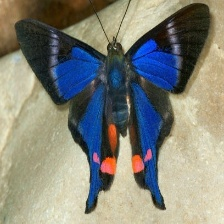

ANSWER: A


In [ ]:
from IPython.display import display

# display a random training example
print('QUESTION:', ds_train.iloc[4]['question'])
display(ds_train.iloc[10]['image'])
print('ANSWER:', ds_train.iloc[4]['answer'])


# STEP 5: Build Gemini SFT JSONL (image + question → answer) and upload to GCS



the JSONL file will look like the following (here the top of the sft_train.jsonl file is shown)



```
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/0.jpg"}}, {"text": "What is the name of the species in this image? Options: A) PURPLE HAIRSTREAK B) CABBAGE WHITE C) COMMON WOOD-NYMPH D) JULIA"}]}, {"role": "model", "parts": [{"text": "A"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/1.jpg"}}, {"text": "What is the name of the species in this image? Options: A) JULIA B) BANDED PEACOCK C) ORANGE OAKLEAF D) PURPLE HAIRSTREAK"}]}, {"role": "model", "parts": [{"text": "D"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/2.jpg"}}, {"text": "Where does this butterfly typically lay its eggs? Options: A) Pine trees B) Oak trees C) Birch trees D) Fruit trees"}]}, {"role": "model", "parts": [{"text": "B"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/3.jpg"}}, {"text": "What is the preferred host plant for this butterfly? Options: A) Oak trees B) Pine trees C) Grass D) Shrubs"}]}, {"role": "model", "parts": [{"text": "A"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/4.jpg"}}, {"text": "What is the name of the species in this image? Options: A) ATLAS MOTH B) COPPER TAIL C) BROOKES BIRDWING D) CHECQUERED SKIPPER"}]}, {"role": "model", "parts": [{"text": "B"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/5.jpg"}}, {"text": "What is the name of the species in this image? Options: A) PEACOCK B) MANGROVE SKIPPER C) COPPER TAIL D) GARDEN TIGER MOTH"}]}, {"role": "model", "parts": [{"text": "C"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/6.jpg"}}, {"text": "Where is this butterfly most commonly found? Options: A) Dense forests B) Open fields C) Coastal dunes D) Urban gardens"}]}, {"role": "model", "parts": [{"text": "A"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/7.jpg"}}, {"text": "What is the preferred environment for this butterfly to reproduce? Options: A) Open fields B) Coastal dunes C) Wetlands D) Urban gardens"}]}, {"role": "model", "parts": [{"text": "A"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/8.jpg"}}, {"text": "What is the name of the species in this image? Options: A) MESTRA B) CLOUDED SULPHUR C) OLEANDER HAWK MOTH D) YELLOW SWALLOW TAIL"}]}, {"role": "model", "parts": [{"text": "B"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/9.jpg"}}, {"text": "What is the name of the species in this image? Options: A) RED CRACKER B) PURPLE HAIRSTREAK C) BANDED ORANGE HELICONIAN D) CLOUDED SULPHUR"}]}, {"role": "model", "parts": [{"text": "D"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/10.jpg"}}, {"text": "What is the primary habitat of this butterfly? Options: A) Grasslands and meadows B) Forest edges C) Mountain regions D) Wetlands"}]}, {"role": "model", "parts": [{"text": "A"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/11.jpg"}}, {"text": "What is the typical color variation seen in this butterfly's wings? Options: A) Yellow B) White C) Pink D) Orange"}]}, {"role": "model", "parts": [{"text": "A"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/12.jpg"}}, {"text": "What is the name of the species in this image? Options: A) TWO BARRED FLASHER B) BANDED ORANGE HELICONIAN C) ADONIS D) BROWN ARGUS"}]}, {"role": "model", "parts": [{"text": "C"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/13.jpg"}}, {"text": "What is the name of the species in this image? Options: A) LUNA MOTH B) PEACOCK C) POLYPHEMUS MOTH D) ADONIS"}]}, {"role": "model", "parts": [{"text": "D"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250915_042548/Dasool/butterflies_and_moths_vqa/train/images/14.jpg"}}, {"text": "What is the typical habitat for this species? Options: A) Grasslands B) Desert plains C) Wetlands D) Forests"}]}, {"role": "model", "parts": [{"text": "A"}]}]}

```



### Output will be a training and validation json file and upload of these + images to Google Storage Bucket

```
📄 Wrote: /content/sft_train.jsonl and /content/sft_validation.jsonl
🟢 Training JSONL: gs://my-gemini-sft-bucket/multimodal_sft_XXXXXXS/Kvasir-VQA-x1/train/sft_train.jsonl
🟢 Validation JSONL: gs://my-gemini-sft-bucket/multimodal_sft_XXXXX/Kvasir-VQA-x1/validation/sft_validation.jsonl
```



View uploads in <font color=red> YOUR</font> bucket.  Console--> Cloud Storage -->Buckets and explore your bucket to see your uploaded data

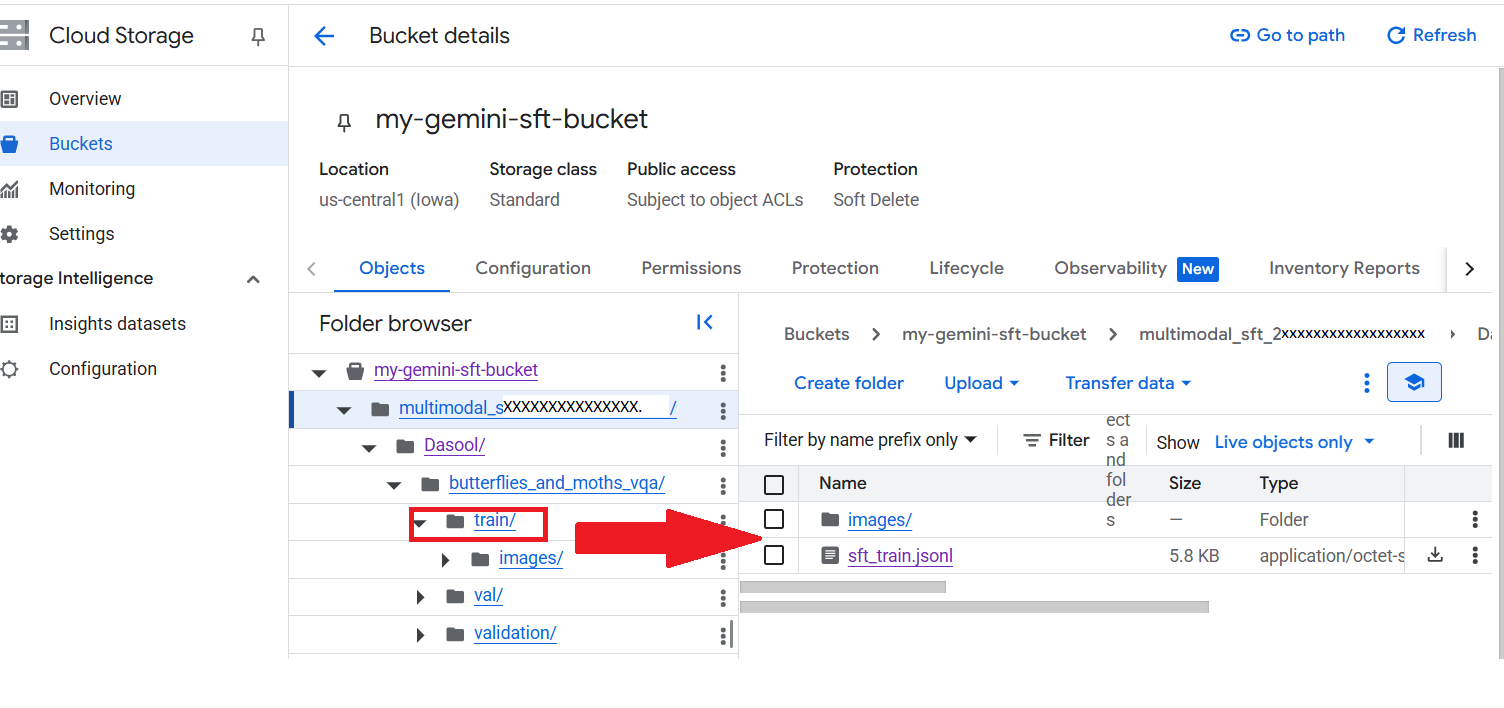

In [ ]:
# Build Gemini SFT JSONL (robust row handling) and upload to GCS
import os, io, json, pathlib, tempfile, mimetypes, requests
from typing import Any, Dict, List, Tuple, Optional
from PIL import Image
from tqdm import tqdm
from google.cloud import storage
import pandas as pd

# -------------------------
# Preconditions / globals
# -------------------------
assert 'ds' in globals(), "Run Step 4 to load a dataset into `ds` first."
assert 'GCS_BUCKET' in globals() and 'PROJECT_ID' in globals(), "Run the auth/setup cell first."

# SELECTED_HF_NAME should be set in Step 4; derive a fallback if not.
if 'SELECTED_HF_NAME' not in globals() or not SELECTED_HF_NAME:
    SELECTED_HF_NAME = (
        getattr(ds, 'builder_name', None)
        or getattr(getattr(next(iter(ds.values())), 'info', None), 'builder_name', None)
        or "dataset"
    )

# TRAIN/VAL split names: respect existing globals; otherwise pick from ds keys
available_splits = list(ds.keys())
def _pick_train(keys):
    for k in ("train","training","Train","TRAIN"):
        if k in keys: return k
    return keys[0] if keys else "train"
def _pick_val(keys):
    for k in ("validation","val","dev","test","Test","TEST"):
        if k in keys: return k
    return "train"

if 'TRAIN_SPLIT' not in globals(): TRAIN_SPLIT = _pick_train(available_splits)
if 'VAL_SPLIT'   not in globals(): VAL_SPLIT   = _pick_val(available_splits)

# Example caps: use UI-provided N_TRAIN/N_VAL if present; else safe fallbacks
MAX_TRAIN_EXAMPLES = globals().get('N_TRAIN', 1000)
MAX_VAL_EXAMPLES   = globals().get('N_VAL',   200)

# GCS object prefix for this run (if not set earlier)
from datetime import datetime
if 'GCS_PREFIX' not in globals() or not GCS_PREFIX:
    GCS_PREFIX = f"gemini_sft/{datetime.now().strftime('%Y%m%d-%H%M%S')}"

print(f"Selected HF dataset: {SELECTED_HF_NAME}")
print(f"Splits: train='{TRAIN_SPLIT}'  val='{VAL_SPLIT}'  (available: {available_splits})")
print(f"Caps: MAX_TRAIN_EXAMPLES={MAX_TRAIN_EXAMPLES}  MAX_VAL_EXAMPLES={MAX_VAL_EXAMPLES}")
print(f"GCS: gs://{GCS_BUCKET}/{GCS_PREFIX}/...")

# -------------------------
# Utilities: access splits
# -------------------------
def _has(name: str) -> bool:
    return name in globals()

def _get_raw_split(name: str):
    """Return a row-indexable collection for the requested split."""
    if name == "train" and _has("ds_train"): return ds_train
    if name in ("validation", "val") and _has("ds_val"): return ds_val
    if name == "test" and _has("ds_test"): return ds_test
    if name in ds: return ds[name]
    # fallback to common alternates
    for alt in ("validation", "val", "test", "train"):
        if alt in ds: return ds[alt]
    raise ValueError(f"Split '{name}' not found. Available: {list(ds.keys())}")

def _row_count(raw) -> int:
    try:
        return len(raw)
    except Exception:
        if isinstance(raw, dict) and raw:
            try:
                return min(len(v) for v in raw.values())
            except Exception:
                return 0
        return 0

def _hf_dataset_type():
    try:
        from datasets import Dataset as HFDataset
        return HFDataset
    except Exception:
        return tuple()

def _get_row(raw, i: int) -> Dict[str, Any]:
    """Return a dict-like example for row i across many container types."""
    HFDataset = _hf_dataset_type()

    # HF Dataset
    if HFDataset and isinstance(raw, HFDataset):
        ex = raw[int(i)]
        return ex if isinstance(ex, dict) else {"value": ex}

    # pandas DataFrame
    if isinstance(raw, pd.DataFrame):
        return raw.iloc[int(i)].to_dict()

    # list/tuple
    if isinstance(raw, (list, tuple)):
        ex = raw[int(i)]
        return ex if isinstance(ex, dict) else {"value": ex}

    # dict-of-lists
    if isinstance(raw, dict) and all(isinstance(v, list) for v in raw.values()):
        out = {}
        for k, v in raw.items():
            if len(v) > i:
                out[k] = v[int(i)]
        return out

    # generic fallback
    try:
        ex = raw[int(i)]
        return ex if isinstance(ex, dict) else {"value": ex}
    except Exception:
        return {"value": raw}

# -------------------------
# Field extraction (robust to arrays/lists)
# -------------------------
def _first_present(ex: Dict[str, Any], keys: List[str]):
    for k in keys:
        if k in ex and ex[k] is not None:
            return ex[k]
    return None

def _to_list_of_str(v: Any) -> List[str]:
    """Coerce v into a list[str]. Handles str, list/tuple, ndarray, list[dict] with 'answer'."""
    try:
        import numpy as np
    except Exception:
        np = None

    if v is None:
        return []

    if isinstance(v, str):
        return [v]

    # HF 'answers' like [{"answer": "x"}, ...]
    if isinstance(v, list) and v and isinstance(v[0], dict) and "answer" in v[0]:
        return [str(d["answer"]) for d in v if "answer" in d]

    if isinstance(v, (list, tuple)):
        return [str(x) for x in v]

    if np is not None and isinstance(v, np.ndarray):
        if v.shape == ():
            return [str(v.item())]
        return [str(x) for x in v.tolist()]

    return [str(v)]

def _get_question_list(ex: Dict[str, Any]) -> List[str]:
    raw = _first_present(ex, ["question", "question_text", "prompt", "Q"])
    return _to_list_of_str(raw)

def _get_answer_list(ex: Dict[str, Any]) -> List[str]:
    raw = _first_present(ex, ["answers", "answer", "label", "A"])
    return _to_list_of_str(raw)

def _get_image_obj(ex: Dict[str, Any]) -> Any:
    return (
        ex.get("image")
        or ex.get("image_path")
        or ex.get("image_url")
        or ex.get("img")
        or ex.get("filepath")
        or ex.get("file")
        or ex.get("path")
    )

# -------------------------
# Image → local path
# -------------------------
def _save_pil_to_tmp(img: Image.Image, suffix=".jpg") -> str:
    fp = tempfile.NamedTemporaryFile(delete=False, suffix=suffix).name
    img.save(fp, "JPEG" if suffix.lower() in (".jpg", ".jpeg") else "PNG")
    return fp

def _to_local_path(obj: Any) -> Optional[str]:
    # PIL.Image.Image
    if isinstance(obj, Image.Image):
        return _save_pil_to_tmp(obj, ".jpg")

    # dict with bytes/path/url
    if isinstance(obj, dict):
        if "bytes" in obj:
            try:
                im = Image.open(io.BytesIO(obj["bytes"]))
                return _save_pil_to_tmp(im, ".jpg")
            except Exception:
                pass
        if "path" in obj:
            return obj["path"]
        if "url" in obj:
            obj = obj["url"]  # fall through to str

    # str: URL or filesystem
    if isinstance(obj, str):
        if obj.startswith(("http://", "https://")):
            r = requests.get(obj, timeout=30)
            r.raise_for_status()
            suffix = pathlib.Path(obj).suffix or ".jpg"
            fp = tempfile.NamedTemporaryFile(delete=False, suffix=suffix).name
            with open(fp, "wb") as f:
                f.write(r.content)
            return fp
        return obj  # assume local path

    # array-like → try PIL
    try:
        im = Image.fromarray(obj)  # type: ignore[arg-type]
        return _save_pil_to_tmp(im, ".jpg")
    except Exception:
        return None

def _guess_mime(path: str) -> str:
    mt, _ = mimetypes.guess_type(path)
    return mt or "image/jpeg"

# -------------------------
# GCS upload
# -------------------------
storage_client = storage.Client(project=PROJECT_ID)
_bucket = storage_client.bucket(GCS_BUCKET)

def _upload(local_path: str, dst_key: str) -> str:
    blob = _bucket.blob(dst_key)
    blob.upload_from_filename(local_path)
    return f"gs://{GCS_BUCKET}/{dst_key}"

# -------------------------
# Collect rows for a split (fans out multi-Q/A)
# -------------------------
def _collect_for_split(split_name: str, max_n: int) -> List[Tuple[str, str, str, str]]:
    """
    Returns list of (question, answer, gs://image_uri, mime) for the split.
    If a sample has multiple Q/A (lists/ndarrays), emit one row per pair,
    reusing the same uploaded image URI.
    """
    raw = _get_raw_split(split_name)
    total = _row_count(raw)
    want = min(max_n, total if total is not None else max_n)
    rows: List[Tuple[str, str, str, str]] = []

    for i in tqdm(range(total), desc=f"Collect {split_name}"):
        if len(rows) >= want:
            break
        ex = _get_row(raw, i)

        img_obj = _get_image_obj(ex)
        if not img_obj:
            continue

        lp = _to_local_path(img_obj)
        if not lp or not pathlib.Path(lp).exists():
            continue

        mime = _guess_mime(lp)
        dst_key = f"{GCS_PREFIX}/{SELECTED_HF_NAME}/{split_name}/images/{i}{pathlib.Path(lp).suffix}"
        uri = _upload(lp, dst_key)

        qs = _get_question_list(ex)
        ans = _get_answer_list(ex)

        if not qs and not ans:
            qs = ["Answer the question about the image."]
            ans = [""]

        # Pair questions and answers sensibly
        if len(qs) > 1 and len(ans) > 1:
            k = min(len(qs), len(ans))
            pairs = zip(qs[:k], ans[:k])
        elif len(qs) > 1 and len(ans) == 1:
            pairs = ((q, ans[0]) for q in qs)
        elif len(qs) == 1 and len(ans) > 1:
            pairs = ((qs[0], a) for a in ans)
        else:
            pairs = ((qs[0] if qs else "", ans[0] if ans else ""),)

        for q, a in pairs:
            rows.append((q, a, uri, mime))
            if len(rows) >= want:
                break

    return rows

# -------------------------
# Build & upload JSONL
# -------------------------
def _write_gemini_jsonl(rows: List[Tuple[str, str, str, str]], out_path: str):
    """
    Each line:
    {"contents":[
       {"role":"user","parts":[{"fileData":{"mimeType": "...","fileUri":"gs://..."}},{"text":"question"}]},
       {"role":"model","parts":[{"text":"answer"}]}
    ]}
    """
    with open(out_path, "w", encoding="utf-8") as f:
        for q, a, uri, mime in rows:
            record = {
                "contents": [
                    {"role": "user", "parts": [
                        {"fileData": {"mimeType": mime, "fileUri": uri}},
                        {"text": q or "Answer the question about the image."}
                    ]},
                    {"role": "model", "parts": [{"text": str(a)}]}
                ]
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

# -------------------------
# Run collection, write, and upload
# -------------------------
train_rows = _collect_for_split(TRAIN_SPLIT, MAX_TRAIN_EXAMPLES)
val_rows   = _collect_for_split(VAL_SPLIT,   MAX_VAL_EXAMPLES)

print(f"✅ Prepared {len(train_rows)} train / {len(val_rows)} val examples (uploaded images to GCS).")

train_jsonl_local = "/content/sft_train.jsonl"
val_jsonl_local   = "/content/sft_validation.jsonl"
_ = _write_gemini_jsonl(train_rows, train_jsonl_local)
_ = _write_gemini_jsonl(val_rows,   val_jsonl_local)
print("📄 Wrote:", train_jsonl_local, "and", val_jsonl_local)

def gs_uri(*parts):
    return "gs://" + "/".join([GCS_BUCKET] + [p.strip("/") for p in parts])

# Keep directory names aligned with actual split names
train_jsonl_gcs = gs_uri(GCS_PREFIX, SELECTED_HF_NAME, TRAIN_SPLIT, "sft_train.jsonl")
val_jsonl_gcs   = gs_uri(GCS_PREFIX, SELECTED_HF_NAME, VAL_SPLIT,   "sft_validation.jsonl")

_bucket.blob(train_jsonl_gcs.replace(f"gs://{GCS_BUCKET}/","")).upload_from_filename(train_jsonl_local)
_bucket.blob(val_jsonl_gcs.replace(f"gs://{GCS_BUCKET}/","")).upload_from_filename(val_jsonl_local)

print("🟢 Training JSONL:", train_jsonl_gcs)
print("🟢 Validation JSONL:", val_jsonl_gcs)


Selected HF dataset: butterflies_and_moths_vqa
Splits: train='train'  val='train'  (available: ['train'])
Caps: MAX_TRAIN_EXAMPLES=15  MAX_VAL_EXAMPLES=10
GCS: gs://my-gemini-sft-bucket/multimodal_sft_20251014_185930/...


Collect train:  67%|██████▋   | 10/15 [00:03<00:01,  2.71it/s]


✅ Prepared 15 train / 10 val examples (uploaded images to GCS).
📄 Wrote: /content/sft_train.jsonl and /content/sft_validation.jsonl
🟢 Training JSONL: gs://my-gemini-sft-bucket/multimodal_sft_20251014_185930/butterflies_and_moths_vqa/train/sft_train.jsonl
🟢 Validation JSONL: gs://my-gemini-sft-bucket/multimodal_sft_20251014_185930/butterflies_and_moths_vqa/train/sft_validation.jsonl


# STEP 6: Start the Gemini supervised fine-tuning job

will see output like


```
 (CLICK ON LINK IN YOUR OUPUT TO SEE JOB)

INFO:vertexai.tuning._tuning:Creating SupervisedTuningJob
Adapter size is  SMALL
Trying signature: epochs / validation_dataset / learning_rate_multiplier
INFO:vertexai.tuning._tuning:SupervisedTuningJob created. Resource name: projects/960115262551/locations/us-central1/tuningJobs/3450221531811020800
INFO:vertexai.tuning._tuning:To use this SupervisedTuningJob in another session:
INFO:vertexai.tuning._tuning:tuning_job = sft.SupervisedTuningJob('projects/960115262551/locations/us-central1/tuningJobs/3450221531811020800')
INFO:vertexai.tuning._tuning:View Tuning Job:
https://console.cloud.google.com/vertex-ai/generative/language/locations/us-central1/tuning/tuningJob/34XXXX800?project=9XXXXXXXX
tune
View Tuning Job
✅ Launched with (epochs, validation_dataset, learning_rate_multiplier)
🚀 Launched tuning job:
   name: 3450221531811020800
```



**NOTE: The full resource name is of your job projects/{PROJECT_ID}/locations/{REGION}/tuningJobs/{TRAINING_JOB_ID}**


***Parameters***

**LRM_ (learning-rate multiplier)**

In Vertex Gemini SFT the service has a recipe with its own default learning-rate schedule (optimizer + warmup/decay).

learning_rate_multiplier scales that internal base LR:
effective_LR = base_LR × LRM_.

Typical, safe ranges:

* 0.5 – 2.0 for most cases

* 0.1 – 0.5 if your dataset is small or noisy (more conservative)

* 2 – 4 if underfitting after a few epochs (more aggressive)

Interactions:

* Higher LR can speed learning but risks divergence/overfit.

* If loss spikes or accuracy gets worse across steps, lower LRM_.

* If loss falls very slowly and predictions look unchanged, raise LRM_ a bit.




**ADAPTER_ (adapter size)**

This is the LoRA/adapter rank (the bottleneck dimension) used for parameter-efficient fine-tuning.

* The base model weights stay frozen; you train small adapter matrices inserted in certain layers.

* Bigger adapter size ⇒ more capacity, better chance to fit complex tasks, but more parameters, memory, and cost.

Typical choices:

* 8 or 16: good starting points for most VQA / classification tasks

* 32: if you have more data or the task is more varied

* <font color=red>4: when you must keep memory/cost very low</font>

Rules of thumb:

* If validation accuracy plateaus well below what you expect and examples are diverse, try increasing adapter size.

* If training accuracy rises but validation doesn’t (overfitting), try smaller adapter and/or lower LRM_ / more regularization (or fewer epochs).

In [ ]:
#STEP 6 — Start the Gemini supervised fine-tuning job (handles SDK arg name changes)
from vertexai.tuning import sft

BASE_MODEL_ = BASE_MODEL
EPOCHS_     = int(EPOCHS)
LRM_        = float(LEARNING_RATE_MULTIPLIER)
ADAPTER_    = ADAPTER_SIZE_NUM


print("Adapter size is ", ADAPTER_SIZE_NUM)

def launch_sft():
    # We’ll try several argument name variants to handle SDK differences.
    base = {
        "source_model": BASE_MODEL_,
        "train_dataset": train_jsonl_gcs,
        "adapter_size": ADAPTER_,
    }
    # possible variants by SDK version:
    epoch_keys = ["epochs", "epoch_count", "num_epochs"]
    val_keys   = ["validation_dataset", "eval_dataset", "validation_data", None]
    lr_keys    = ["learning_rate_multiplier", "learning_rate", None]

    last_err = None
    for ek in epoch_keys:
        for vk in val_keys:
            for lk in lr_keys:
                kwargs = base.copy()
                kwargs[ek] = EPOCHS_
                if vk: kwargs[vk] = val_jsonl_gcs
                if lk: kwargs[lk] = LRM_
                try:
                    print(f"Trying signature: {ek} / {vk or '(no-val-key)'} / {lk or '(no-lr-key)'}")
                    job = sft.train(**kwargs)
                    print(f"✅ Launched with ({ek}, {vk or '—'}, {lk or '—'})")
                    return job
                except TypeError as e:
                    # wrong signature for this SDK version — try next combo
                    last_err = e
                except Exception as e:
                    # real runtime error (e.g., bad dataset URI) — surface immediately
                    raise
    raise TypeError(f"Could not find a working sft.train signature for this SDK.\nLast error: {last_err}")

tuning_job = launch_sft()

print("🚀 Launched tuning job:")
print("   name:", tuning_job.name)  # projects/.../locations/.../tuningJobs/...
# If you still have `tuning_job` in memory, this will work:
job_id_or_name = tuning_job.name if 'tuning_job' in globals() else "3450221531811020800"  # ← paste ID if needed
globals()['job_id_or_name'] = job_id_or_name  # now available to later

INFO:vertexai.tuning._tuning:Creating SupervisedTuningJob


Adapter size is  4
Trying signature: epochs / validation_dataset / learning_rate_multiplier


INFO:vertexai.tuning._tuning:SupervisedTuningJob created. Resource name: projects/960115262551/locations/us-central1/tuningJobs/5760170392320737280
INFO:vertexai.tuning._tuning:To use this SupervisedTuningJob in another session:
INFO:vertexai.tuning._tuning:tuning_job = sft.SupervisedTuningJob('projects/960115262551/locations/us-central1/tuningJobs/5760170392320737280')
INFO:vertexai.tuning._tuning:View Tuning Job:
https://console.cloud.google.com/vertex-ai/generative/language/locations/us-central1/tuning/tuningJob/5760170392320737280?project=960115262551


✅ Launched with (epochs, validation_dataset, learning_rate_multiplier)
🚀 Launched tuning job:
   name: 5760170392320737280


## STEP 6.1 State status of training

In Vertex AI (the service backing Gemini fine-tuning), the state field is an enum.

For SupervisedTuningJob the values map like this:

1 → STATE_UNSPECIFIED (default / not set)

2 → PENDING (job created, not yet running)

3 → RUNNING 🚀 (your training job is actively running right now)

4 → SUCCEEDED (finished successfully)

5 → FAILED

6 → CANCELLING

7 → CANCELLED

In [ ]:
#STEP 6.1 — Inspect a specific tuning job (status, tuned endpoint)
from vertexai.tuning import sft


def _full_job_name(j):
    # Accept either just the numeric ID or the full resource name
    if "/" in j:
        return j
    return f"projects/{PROJECT_ID}/locations/{REGION}/tuningJobs/{j}"

name = _full_job_name(job_id_or_name)
job = sft.SupervisedTuningJob(name).refresh()

print("Job name:   ", job.name)
print("State:      ", job.state)
print("Create time:", getattr(job, "create_time", None))
print("Start time: ", getattr(job, "start_time", None))
print("End time:   ", getattr(job, "end_time", None))

# If finished, a tuned model reference is usually attached:
tm = getattr(job, "tuned_model", None)
if tm:
    print("Tuned model:", tm)
    # Some SDK versions expose an endpoint under tuned_model.endpoint
    if hasattr(tm, "endpoint"):
        print("Endpoint:   ", tm.endpoint)
else:
    print("Tuned model: (not available yet — job is still running)")


/usr/local/lib/python3.12/dist-packages/vertexai/tuning/_tuning.py:74: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Job name:    38092253926785024
State:       3
Create time: 2025-09-27 20:16:16.194293+00:00
Start time:  None
End time:    None
Tuned model: (not available yet — job is still running)


# STEP 7 : Inspect job & list all jobs

In [ ]:
#STEP 7 — Inspect this tuning job & list all jobs
from vertexai.tuning import sft

assert 'job_id_or_name' in globals(), "Run STEP 6 first to set job_id_or_name."

def _full_job_name(j):
    return j if "/" in j else f"projects/{PROJECT_ID}/locations/{REGION}/tuningJobs/{j}"

name = _full_job_name(job_id_or_name)
job  = sft.SupervisedTuningJob(name).refresh()

print("Job:", job.name)
print("State:", job.state)
print("Create:", getattr(job, "create_time", None))
print("Start :", getattr(job, "start_time", None))
print("End   :", getattr(job, "end_time", None))
tm = getattr(job, "tuned_model", None)
print("Tuned model:", tm if tm else "(not ready yet)")

print("\nAll jobs in project/region:")
for j in sft.SupervisedTuningJob.list():
    print(" •", j.name, "→", j.state, getattr(j, "tuned_model", None))


Job: 38092253926785024
State: 3
Create: 2025-09-27 20:16:16.194293+00:00
Start : None
End   : None
Tuned model: (not ready yet)

All jobs in project/region:
 • 38092253926785024 → 3 None
 • 5414031212635226112 → 4 None
 • 2108248348656926720 → 4 None
 • 5674646804499529728 → 4 None
 • 4035688383857557504 → 4 None
 • 4726005764240441344 → 4 None
 • 5281531815151009792 → 4 None
 • 3343261040660971520 → 4 None
 • 3450221531811020800 → 4 None
 • 2811519625282453504 → 4 None
 • 4242538406879428608 → 4 None


## STEP 7.1 optional poll for results

In [ ]:
#STEP 7.1 — Poll this job until it finishes (robust state handling)
import time
from vertexai.tuning import sft

assert 'job_id_or_name' in globals(), "Run STEP 6 first."
name = job_id_or_name if "/" in job_id_or_name else f"projects/{PROJECT_ID}/locations/{REGION}/tuningJobs/{job_id_or_name}"

def _state_num(s):
    # Try to coerce enum/str/int to an int code
    try:
        return int(s)
    except Exception:
        return getattr(s, "value", None) or getattr(s, "number", None)

def _state_name(s):
    return getattr(s, "name", "") or str(s)

print("⏳ Monitoring:", name)
while True:
    job = sft.SupervisedTuningJob(name).refresh()
    st = job.state
    st_num = _state_num(st)
    st_name = _state_name(st)

    print(f"state: num={st_num} name={st_name} raw={st}")

    # 4 = SUCCEEDED, 5 = FAILED, 6 = CANCELLING, 7 = CANCELLED
    if st_num == 4 or "SUCCEEDED" in st_name or "SUCCEEDED" in str(st):
        print("✅ Job succeeded.")
        globals()['TUNED_MODEL_REF'] = getattr(job, "tuned_model", None)
        break
    if st_num in (5, 7) or "FAILED" in st_name or "CANCELLED" in st_name:
        raise RuntimeError(f"❌ Job finished with terminal state: {st}")

    time.sleep(30)


⏳ Monitoring: projects/demoproject-438016/locations/us-central1/tuningJobs/38092253926785024


state: num=3 name=JOB_STATE_RUNNING raw=3


state: num=3 name=JOB_STATE_RUNNING raw=3


state: num=3 name=JOB_STATE_RUNNING raw=3


state: num=3 name=JOB_STATE_RUNNING raw=3


state: num=3 name=JOB_STATE_RUNNING raw=3


state: num=3 name=JOB_STATE_RUNNING raw=3


state: num=3 name=JOB_STATE_RUNNING raw=3


state: num=4 name=JOB_STATE_SUCCEEDED raw=4
✅ Job succeeded.


### similar alternative

In [ ]:
# Poll Vertex Supervised Tuning Job via the **regional** REST host
import time, json, requests
from google.auth import default
from google.auth.transport.requests import Request

# Reuse your existing vars from Step 6 parsing:
PROJECT_ID = PROJECT_ID          # "demoproject-438016"
LOCATION   = REGION              # "us-central1"
#JOB_ID     = "4726005764240441344"
JOB_ID = job_id_or_name

BASE = f"https://{LOCATION}-aiplatform.googleapis.com/v1"
URL  = f"{BASE}/projects/{PROJECT_ID}/locations/{LOCATION}/tuningJobs/{JOB_ID}"

def make_headers():
    creds, _ = default(scopes=["https://www.googleapis.com/auth/cloud-platform"])
    creds.refresh(Request())
    return {"Authorization": f"Bearer {creds.token}"}

terminal_states = {"SUCCEEDED","FAILED","CANCELLING","CANCELLED"}

while True:
    r = requests.get(URL, headers=make_headers(), timeout=30)
    if r.status_code >= 400:
        try:
            print("❌", r.status_code, r.json())
        except Exception:
            print("❌", r.status_code, r.text)
        break

    job = r.json()
    state = job.get("state") or job.get("jobState") or "STATE_UNSPECIFIED"
    print("-"*80)
    print("State:", state, "| start:", job.get("startTime"), "| end:", job.get("endTime"))
    tuned = job.get("tunedModel")
    if tuned:
        print("Tuned model:", tuned)

    # Common places to surface progress/metrics-like info
    stats = job.get("tuningDataStatistics") or job.get("tuning_data_statistics")
    if stats:
        print("\nTuning data statistics:")
        print(json.dumps(stats, indent=2))

    metrics = (job.get("metrics") or job.get("evaluationMetrics") or
               job.get("trainingMetrics"))
    if metrics:
        print("\nMetrics:")
        print(json.dumps(metrics[:5] if isinstance(metrics, list) else metrics, indent=2))
    else:
        print("\n(no metrics node yet; some appear only after first eval checkpoint)")

    if any(s in state for s in terminal_states):
        print("\n✅ Job reached terminal state:", state)
        break

    time.sleep(30)


--------------------------------------------------------------------------------
State: JOB_STATE_SUCCEEDED | start: 2025-09-27T20:16:16.244252Z | end: 2025-09-27T20:30:07.368676Z
Tuned model: {'model': 'projects/960115262551/locations/us-central1/models/6647289960254668800@1', 'endpoint': 'projects/960115262551/locations/us-central1/endpoints/4871728214977806336', 'checkpoints': [{'checkpointId': '1', 'epoch': '1', 'step': '1', 'endpoint': 'projects/960115262551/locations/us-central1/endpoints/260042196550418432'}, {'checkpointId': '2', 'epoch': '2', 'step': '2', 'endpoint': 'projects/960115262551/locations/us-central1/endpoints/4871728214977806336'}]}

(no metrics node yet; some appear only after first eval checkpoint)

✅ Job reached terminal state: JOB_STATE_SUCCEEDED


# STEP 8: Fetch tuned endpoint & try a few predictions

example of one test sample from Gastrointestinal dataset

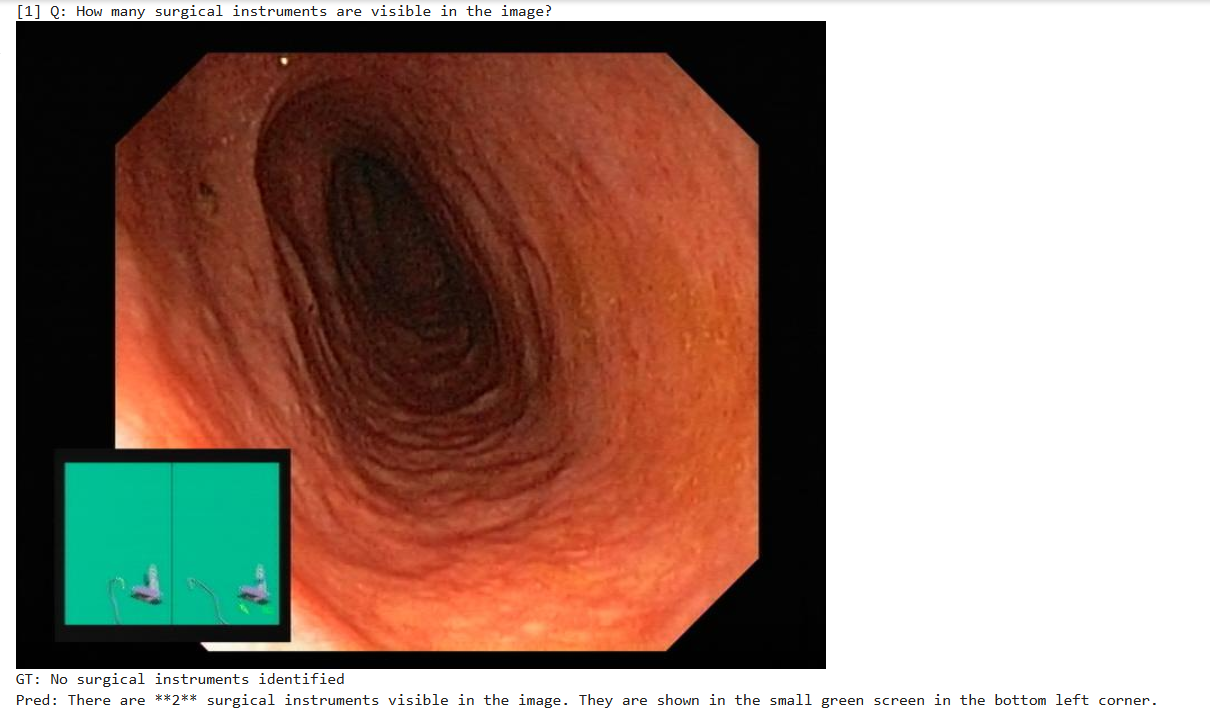

Job state: 4


🟢 Tuned endpoint: projects/960115262551/locations/us-central1/endpoints/4871728214977806336
Testing 5 validation samples (showing images)…

[1] Q: What is the name of the species in this image? Options: A) PURPLE HAIRSTREAK B) CABBAGE WHITE C) COMMON WOOD-NYMPH D) JULIA


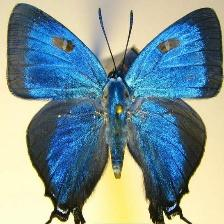

GT: A
Pred: The butterfly in the image displays iridescent blue wings with black margins and some small spots on the forewings.

Let's evaluate the options:
*   **A) PURPLE HAIRSTREAK:** Purple Hairstreaks (e.g., *Neozephyrus quercus*) are known for their beautiful iridescent purplish-blue upperwings, especially in males, and dark borders. The color and pattern in the image are highly consistent with a Purple Hairstreak or a closely related blue hairstreak species.
*   **B) CABBAGE WHITE:** Cabbage Whites (*Pieris rapae*) are typically white with black tips on the forewings and one or two black spots. They do not have blue wings.
*   **C) COMMON WOOD-NYMPH:** Common Wood-Nymphs (*Cercyonis pegala*) are typically brown with prominent eyespots (ocelli) on their wings. They do not have blue wings.
*   **D) JULIA:** Julia butterflies (*Dryas iulia*) are orange with black markings. They do not have blue wings.

Based on the distinctive iridescent blue coloration, the butterfly in the image 

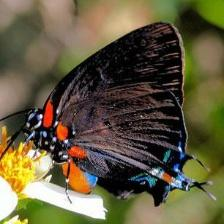

GT: D
Pred: The butterfly in the image is a **Great Purple Hairstreak** (*Atlides halesus*).

Key features that identify it as a hairstreak butterfly, and specifically this type:
*   **Tails on hindwings:** Hairstreaks are known for the small, delicate tails on their hindwings.
*   **Dark wings:** The predominant color of the wings is dark, often black or dark brown.
*   **Bright coloration on the body and hindwings:** This species exhibits striking iridescent blue patches on the hindwings, and bright red/orange patches on the underside of the hindwings and sometimes on the body near the head, as seen in the image.

Among the given options, **D) PURPLE HAIRSTREAK** is the correct category for this butterfly.

[3] Q: Where does this butterfly typically lay its eggs? Options: A) Pine trees B) Oak trees C) Birch trees D) Fruit trees


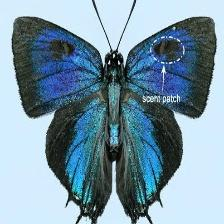

GT: B
Pred: The butterfly in the image is the **Great Blue Hairstreak** (*Oenomaus ortygnus*), a species found in Central and South America.

Its larvae are known to feed on plants from the genera *Inga* (in the pea family, Fabaceae) and *Serjania* (in the soapberry family, Sapindaceae).

*   **Inga** species are often called "ice-cream-bean" trees and are known for their edible pods, making them a type of fruit tree.
*   **Sapindaceae** (which includes *Serjania*) is a family that also contains well-known fruit trees like lychee, longan, and rambutan.

Therefore, among the given options, **D) Fruit trees** is the most appropriate general category for the host plants of this butterfly, as its specific host plants are either fruit-bearing or belong to families known for fruit trees.

The final answer is $\boxed{D}$

[4] Q: What is the preferred host plant for this butterfly? Options: A) Oak trees B) Pine trees C) Grass D) Shrubs


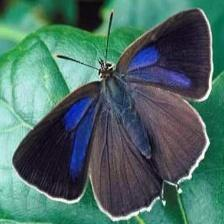

GT: A
Pred: The butterfly in the image is an **Oak Blue** (specifically, it strongly resembles a female Purple Hairstreak, *Favonius quercus*, which is often referred to as the "Oak Blue" in some regions).

The preferred host plant for the Oak Blue butterfly is **A) Oak trees**. Their caterpillars feed almost exclusively on the leaves of various oak species.

[5] Q: What is the name of the species in this image? Options: A) ATLAS MOTH B) COPPER TAIL C) BROOKES BIRDWING D) CHECQUERED SKIPPER


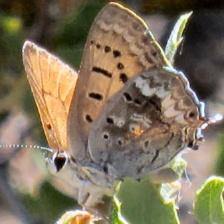

GT: B
Pred: Let's analyze the image and the given options:

1.  **Image Analysis:** The image shows a small butterfly with its wings closed, displaying the underside. It has a delicate body, clubbed antennae, and its wings are mostly light brown or grayish-brown with distinct darker spots and some wavy lines. There might be a very tiny projection at the hindwing margin, but not a prominent tail.

2.  **Evaluating the Options:**

    *   **A) ATLAS MOTH:** Atlas moths are very large, robust moths with distinct "snake head" patterns on their wingtips and reddish-brown coloration. The creature in the image is a small, delicate butterfly, not a moth. So, **A is incorrect**.

    *   **B) COPPER TAIL:** This term isn't a universally recognized single species common name, but "Coppers" are a group of small butterflies (genus *Lycaena*) within the family Lycaenidae. Many butterflies in the Lycaenidae family (which includes Blues, Coppers, and Hairstreaks) are small, have delicate bodies, and 

In [ ]:
#STEP 8 — Fetch tuned endpoint (Vertex AI client) and test + DISPLAY IMAGES
from google import genai
from google.genai.types import HttpOptions
from vertexai.tuning import sft
from google.cloud import storage
from IPython.display import display
from PIL import Image
import io, requests, re, pathlib

assert 'job_id_or_name' in globals(), "Run STEP 6 first."

# Build full job name if user only saved the numeric ID
name = job_id_or_name if "/" in job_id_or_name else f"projects/{PROJECT_ID}/locations/{REGION}/tuningJobs/{job_id_or_name}"

# ✅ Init the Google GenAI client for **Vertex AI** (Cloud)
client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=REGION,
    http_options=HttpOptions(api_version="v1"),
)

# Get tuned endpoint (SDK first, then Tunings API)
job = sft.SupervisedTuningJob(name).refresh()
print("Job state:", job.state)

endpoint = None
tm = getattr(job, "tuned_model", None)
if tm and getattr(tm, "endpoint", None):
    endpoint = tm.endpoint
if endpoint is None:
    tuned = client.tunings.get(name=name)
    if getattr(tuned, "tuned_model", None):
        endpoint = tuned.tuned_model.endpoint

if not endpoint:
    raise RuntimeError("Tuned endpoint not available yet. Confirm the job has SUCCEEDED (see STEP 7/7.1 or Console).")

print("🟢 Tuned endpoint:", endpoint)
globals()['endpoint'] = endpoint  # expose for later steps

# ---------- helpers to load & display images ----------
_storage = storage.Client(project=PROJECT_ID)

def _load_image(uri_or_path):
    """Return a PIL.Image from gs://, http(s)://, or local path."""
    if isinstance(uri_or_path, str) and uri_or_path.startswith("gs://"):
        # gs://bucket/key
        m = re.match(r"gs://([^/]+)/(.+)", uri_or_path)
        if not m:
            return None
        bkt, key = m.group(1), m.group(2)
        blob = _storage.bucket(bkt).blob(key)
        data = blob.download_as_bytes()
        return Image.open(io.BytesIO(data)).convert("RGB")
    if isinstance(uri_or_path, str) and uri_or_path.startswith(("http://","https://")):
        r = requests.get(uri_or_path, timeout=30)
        r.raise_for_status()
        return Image.open(io.BytesIO(r.content)).convert("RGB")
    # local file path (rare in this flow)
    p = pathlib.Path(str(uri_or_path))
    if p.exists():
        return Image.open(p).convert("RGB")
    return None

def _safe_text(resp):
    try:
        return (resp.text or "").strip()
    except Exception:
        parts = getattr(resp, "candidates", []) or []
        for c in parts:
            content = getattr(c, "content", None)
            if content:
                for part in getattr(content, "parts", []) or []:
                    if isinstance(part, dict) and "text" in part:
                        return part["text"].strip()
        return ""

# ---- Test a few validation examples & DISPLAY the image ----
assert 'val_rows' in globals() and len(val_rows), "Run STEP 5 to prepare val_rows."
NUM_PREVIEW = 5  # change if you want more/less
preview = val_rows[:min(NUM_PREVIEW, len(val_rows))]

print(f"Testing {len(preview)} validation samples (showing images)…")

for i, (q, a, uri, mime) in enumerate(preview, start=1):
    print(f"\n[{i}] Q:", q)
    img = _load_image(uri)
    if img:
        display(img)
    else:
        print("(Image preview unavailable)")

    prompt = [
        {"role":"user","parts":[
            {"file_data": {"file_uri": uri, "mime_type": mime}},
            {"text": q or "Answer the question about the image."}
        ]}
    ]
    resp = client.models.generate_content(model=endpoint, contents=prompt)
    pred = _safe_text(resp)

    print("GT:", a)
    print("Pred:", pred)


## STEP 8.1 ALTERNATIVE Using Model ID run Inference/Test

 * Uses the Tuning Job ID (the one you already printed out above and set to globals) to fetch the tuned endpoint reliably, and note below it will print out something like
 Tuned endpoint: projects/9XXXXXX51/locations/us-central1/endpoints/1XXXXXXXXXXXX8
 Tuned endpoint: projects/960115262551/locations/us-central1/endpoints/1425981918830133248
Testing 5 validation samples (showing images)…




* Runs a smoke test showing each image + question, ground truth, and prediction.




NOTE: you can find your endpoint by going to Google Cloud Console ->Vertex AI -> endpoints finding your trained model and noting its ID --you must also know your project number and location

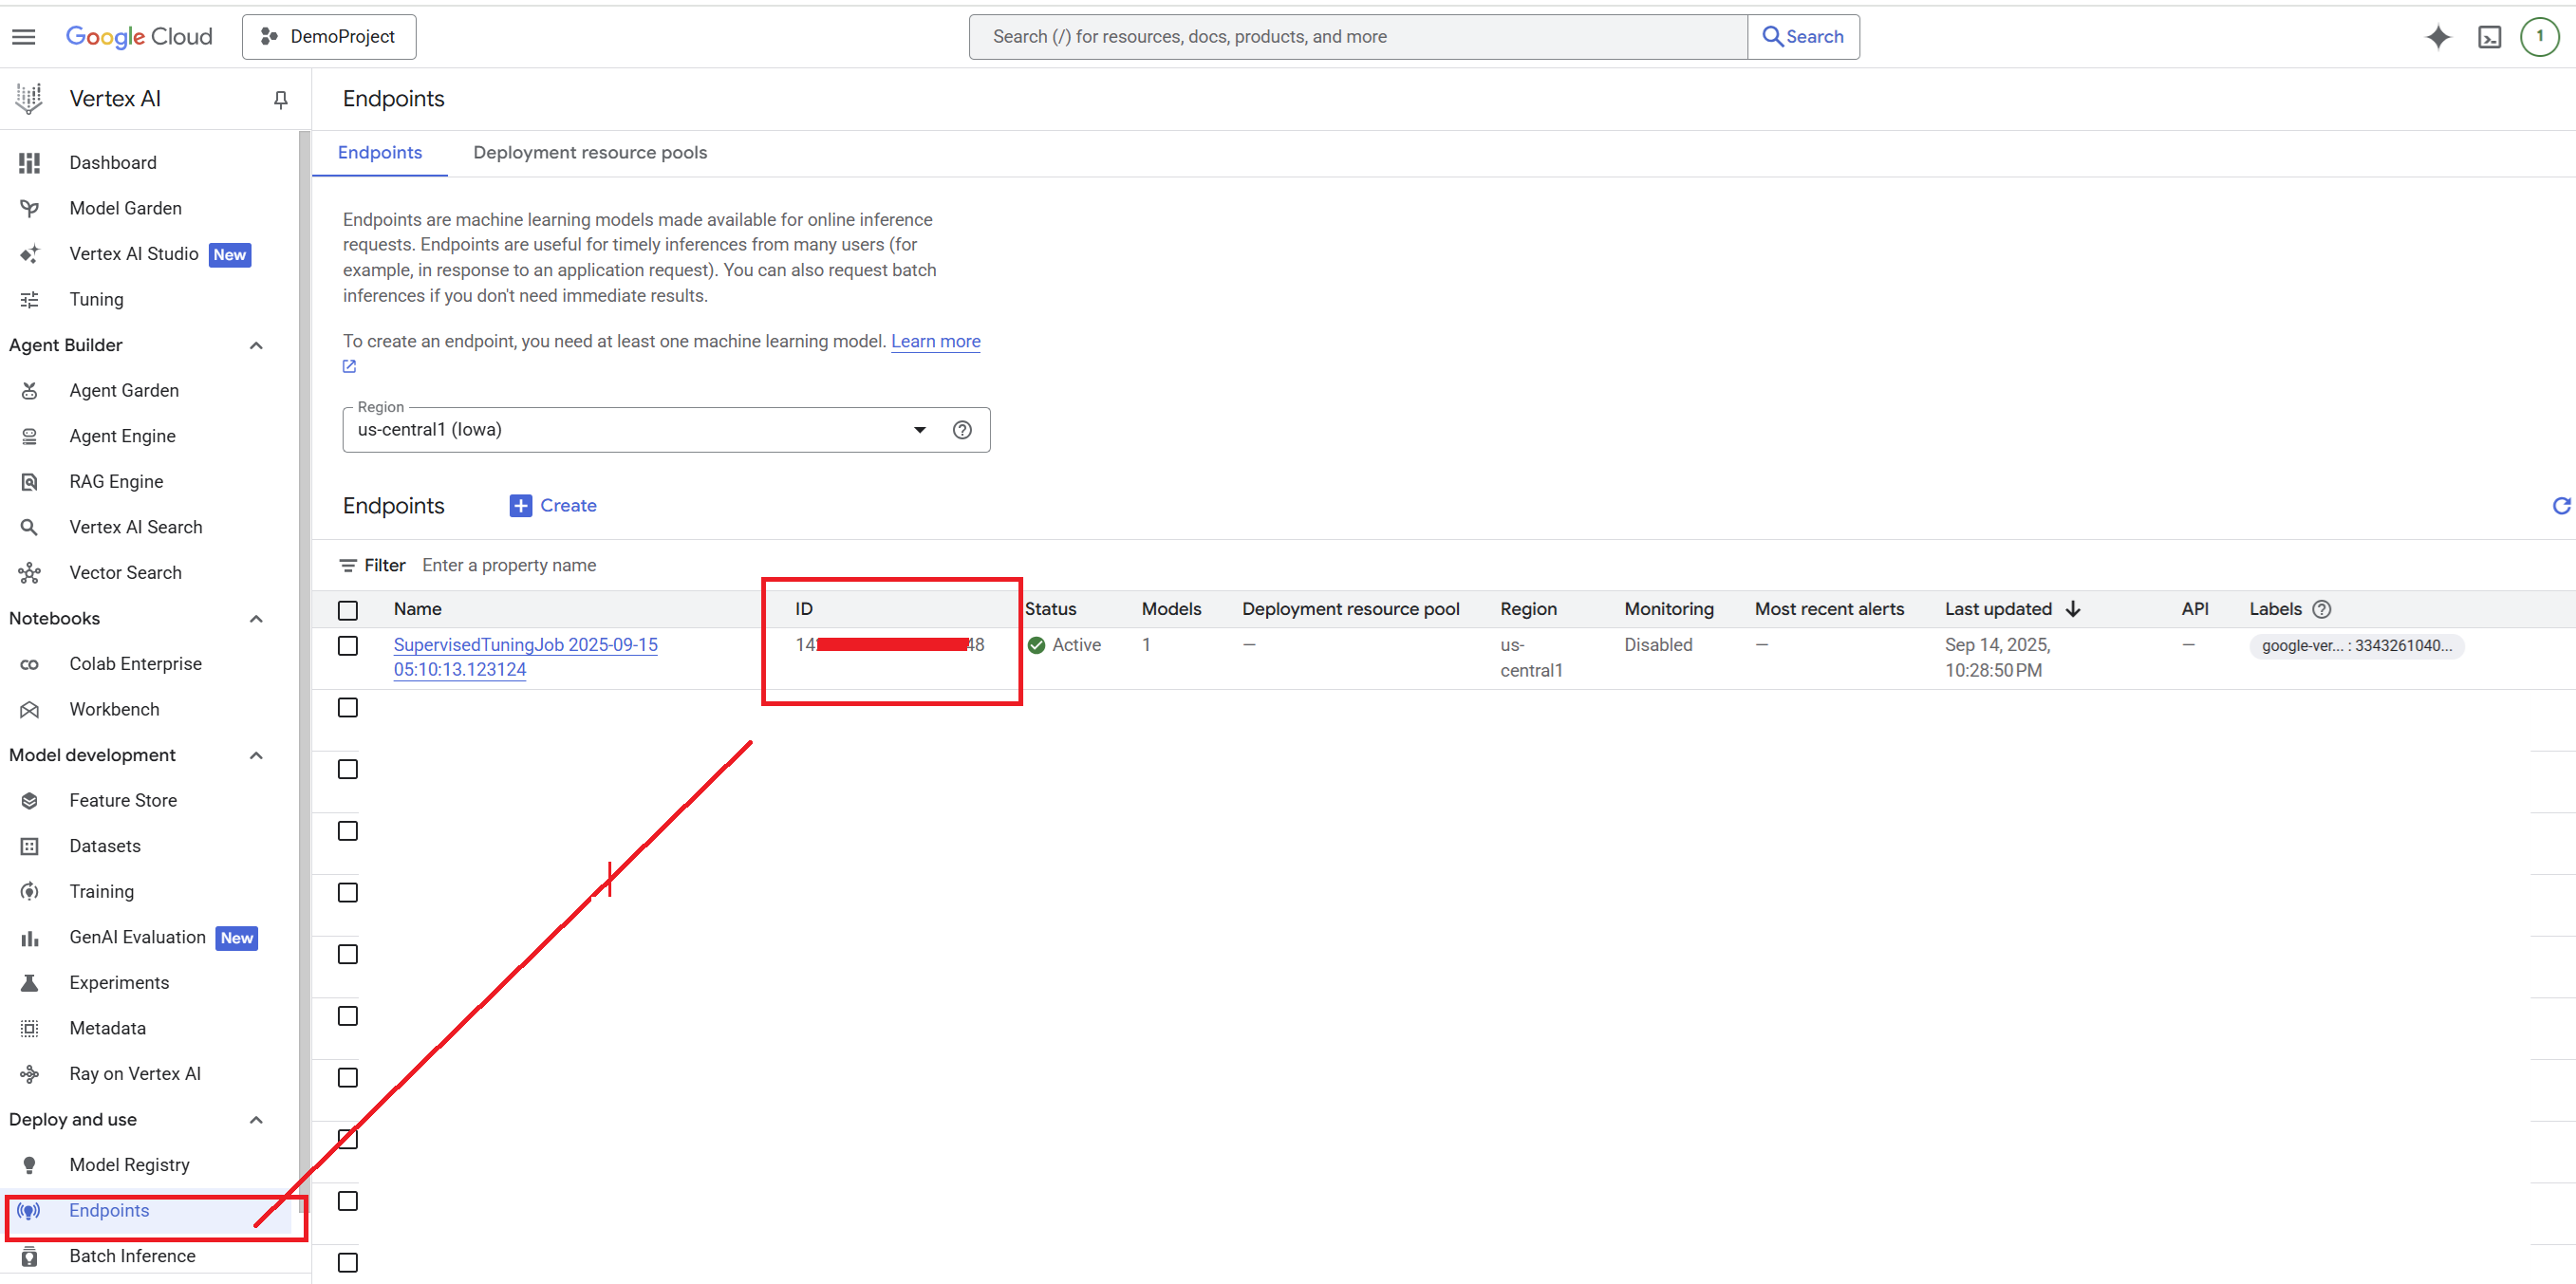

Job state: 4
🟢 Tuned endpoint: projects/960115262551/locations/us-central1/endpoints/4871728214977806336
Testing 10 validation samples (showing images)…

[1] Q: What is the name of the species in this image? Options: A) PURPLE HAIRSTREAK B) CABBAGE WHITE C) COMMON WOOD-NYMPH D) JULIA


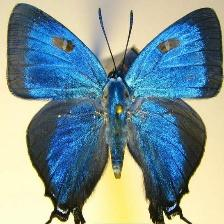

GT: A
Pred: The butterfly in the image displays a striking iridescent blue coloration with dark borders on its wings. Let's evaluate the given options:

*   **A) PURPLE HAIRSTREAK (Favonius quercus):** Males of the Purple Hairstreak are known for their brilliant iridescent purplish-blue upperwings with dark borders, which can appear quite blue depending on the light. The butterfly in the image strongly matches this description, especially the vibrant blue iridescence and wing shape.

*   **B) CABBAGE WHITE (Pieris rapae):** Cabbage Whites are white butterflies with small black spots, not blue. This is incorrect.

*   **C) COMMON WOOD-NYMPH (Cercyonis pegala):** Common Wood-Nymphs are typically brown with prominent eyespots, not blue or iridescent in this manner. This is incorrect.

*   **D) JULIA (Dryas iulia):** Julia butterflies are bright orange with black markings, not blue. This is incorrect.

Based on the distinctive iridescent blue wings with dark borders, the butterfly in the i

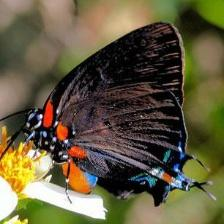

GT: D
Pred: The butterfly in the image is an **Atala butterfly** (*Eumaeus atala*).

Let's evaluate the options:
*   A) JULIA: Julia butterflies are typically orange with black markings. This does not match the image.
*   B) BANDED PEACOCK: Banded Peacock butterflies are red and black with distinct white bands. This does not match the image.
*   C) ORANGE OAKLEAF: Orange Oakleaf butterflies have a distinctive leaf-like camouflage on their underside and typically different patterns on their upperside. This does not match the image.
*   D) PURPLE HAIRSTREAK: While the common "Purple Hairstreak" (*Neozephyrus quercus*) specific to Europe has a more uniform purple iridescence, the term "Hairstreak" refers to a large subfamily of butterflies (Theclinae) characterized by small, tail-like appendages on their hindwings, which are clearly visible in the image. The Atala butterfly itself belongs to the Hairstreak subfamily. Among the given options, "Hairstreak" is the correct classification for 

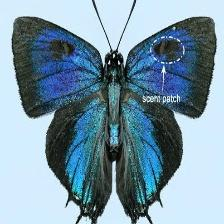

GT: B
Pred: The butterfly in the image is a **Morpho butterfly**, likely a species like *Morpho menelaus* or *Morpho didius*, known for their iridescent blue wings.

Morpho butterflies typically lay their eggs on the underside of leaves of specific host plants. These host plants are often woody vines, shrubs, or trees, primarily from the **Leguminosae (Fabaceae)**, **Malpighiaceae**, **Menispermaceae**, and **Sapindaceae** families.

Let's evaluate the given options:
*   **A) Pine trees:** Conifers are not typical host plants for Morpho butterflies.
*   **B) Oak trees:** Trees in the *Quercus* genus are not typical host plants for Morpho butterflies.
*   **C) Birch trees:** Trees in the *Betula* genus are not typical host plants for Morpho butterflies.
*   **D) Fruit trees:** This is a broad category. However, many plants in the Leguminosae, Malpighiaceae, and Sapindaceae families (which are common host plants for Morpho butterflies) are indeed considered "fruit trees" or produce edibl

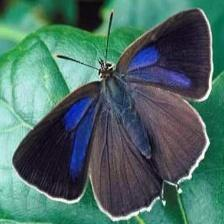

GT: A
Pred: This butterfly is likely a species of **hairstreak**, belonging to the family Lycaenidae. Many hairstreak species, particularly those in the genus *Satyrium* and related genera, have a strong association with **oak trees** for their larval host plants.

Based on the common host plants for butterflies that look like this, the preferred host plant is:

**A) Oak trees**

[5] Q: What is the name of the species in this image? Options: A) ATLAS MOTH B) COPPER TAIL C) BROOKES BIRDWING D) CHECQUERED SKIPPER


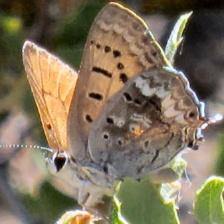

GT: B
Pred: Based on the image:

1.  **Atlas Moth:** These are very large moths, often with a wingspan of up to 1 foot, distinctive patterns, and no clubbed antennae like the creature in the image. The image shows a small butterfly.
2.  **Brookes Birdwing:** These are large, tropical butterflies known for their striking black, green, and yellow patterns. The butterfly in the image is small and predominantly brown/tan.
3.  **Chequered Skipper:** Skippers have a more robust body and often a distinct resting posture (wings partially open, forewings and hindwings at different angles) and antennae with a hook at the end. While some skippers can have spotted undersides, the delicate appearance and wing shape in the image are more typical of a 'blue' or 'copper' butterfly (Lycaenidae family) than a skipper (Hesperiidae family).
4.  **Copper Tail:** The butterfly in the image is small, with a muted brown/tan underside adorned with a series of small, dark spots, some ringed with lighter color. 

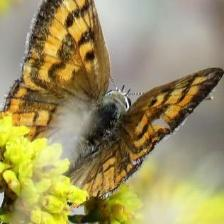

GT: C
Pred: The butterfly in the image displays characteristics typical of a "Copper" butterfly, belonging to the genus *Lycaena*. They are known for their coppery-orange wings with black spots and markings.

Let's evaluate the options:
*   **A) PEACOCK:** Peacock butterflies (*Aglais io*) are known for their distinctive large "eyespot" patterns, which are not present in the image.
*   **B) MANGROVE SKIPPER:** Skippers generally have stouter bodies and hooked antennae tips, and their wing patterns are typically different. The butterfly in the image is not a skipper.
*   **C) COPPER TAIL:** While "Copper Tail" isn't a widely recognized standard common name for a specific species, the term "Copper" directly refers to the group of butterflies that this specimen belongs to (*Lycaena* species, e.g., Small Copper, American Copper). The butterfly in the image is clearly a "Copper" butterfly.
*   **D) GARDEN TIGER MOTH:** This is a moth, not a butterfly, and has very different wing patterns (o

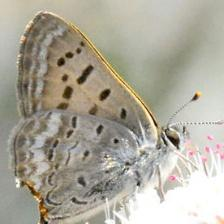

GT: A
Pred: The butterfly in the image appears to be a type of **blue butterfly** (family Lycaenidae). Many species of blue butterflies, and indeed many small butterflies in general, are most commonly found in habitats with abundant sunlight and flowering plants.

Let's evaluate the options:
*   **A) Dense forests:** Dense forests are often too shady and lack the specific host plants and nectar sources many small butterflies prefer.
*   **B) Open fields:** Open fields, meadows, grasslands, and clearings are ideal habitats for many blue butterflies. They provide ample sunlight, a variety of wildflowers for nectar, and often the leguminous host plants their larvae feed on. This is a very strong candidate.
*   **C) Coastal dunes:** While some specialized butterfly species can be found in coastal dune environments, it's not the most common habitat for the majority of small butterflies, especially compared to open fields.
*   **D) Urban gardens:** Butterflies do visit urban gardens for nect

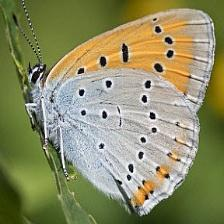

GT: A
Pred: Based on the appearance of the butterfly, it is a type of Copper butterfly, likely a Small Copper (*Lycaena phlaeas*) or a closely related species.

Copper butterflies, particularly the Small Copper, primarily lay their eggs on plants from the genus *Rumex*, such as Common Sorrel (*Rumex acetosa*) and Sheep's Sorrel (*Rumex acetosella*). These plants are commonly found in:

*   **Open fields:** Meadows, pastures, grassy areas, heathlands, and disturbed ground.

Let's evaluate the options:
*   **A) Open fields:** This is a strong candidate, as it perfectly matches the habitat of their host plants.
*   **B) Coastal dunes:** While some specialized butterflies live here, *Rumex* species are not typical dominant dune plants.
*   **C) Wetlands:** While some *Rumex* species can tolerate damp conditions (e.g., Common Sorrel in damp meadows), "wetlands" generally implies more waterlogged environments, which are not the primary habitat for most Copper butterflies' host plants. Some s

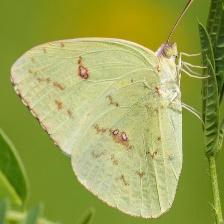

GT: B
Pred: The butterfly in the image has pale yellowish-green wings with some scattered reddish-brown spots, particularly noticeable on the underside. Its overall shape and coloration are characteristic of a "sulphur" butterfly.

Let's evaluate the options:
*   **A) MESTRA:** Mestra butterflies are generally smaller, brownish, and have different wing patterns. This does not match the image.
*   **B) CLOUDED SULPHUR:** Clouded Sulphurs (*Colias philodice*) are common North American butterflies that can be yellow, white, or greenish-yellow. The pale greenish-yellow coloration, especially on the underside, and the presence of faint reddish spots are very consistent with a Clouded Sulphur (or a closely related *Colias* species like the Orange Sulphur, which can also appear greenish).
*   **C) OLEANDER HAWK MOTH:** Oleander Hawk Moths are large, stout-bodied moths with very elaborate green, pink, and white patterns, completely different from the butterfly in the image.
*   **D) YELLOW SWA

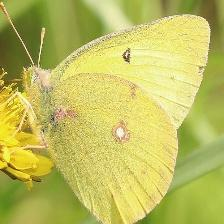

GT: D
Pred: The butterfly in the image is bright yellow with a small dark spot on the forewing and a distinctive white-centered spot on the hindwing. These are characteristic features of a **Clouded Sulphur** butterfly.

The correct answer is **D) CLOUDED SULPHUR**.


In [ ]:
#STEP 8.1 — Resolve tuned endpoint from Tuning Job ID and test (show images)
from google import genai
from google.genai.types import HttpOptions
from vertexai.tuning import sft
from google.cloud import storage
from IPython.display import display
from PIL import Image
import io, requests, re, pathlib

assert 'job_id_or_name' in globals(), "Run STEP 6 first to set job_id_or_name."

# Build full job resource name if only an ID was saved
JOB_NAME = job_id_or_name if "/" in job_id_or_name else f"projects/{PROJECT_ID}/locations/{REGION}/tuningJobs/{job_id_or_name}"

# Init GenAI client for **Vertex AI (Cloud)** (uses your gcloud auth from vertexai.init)
client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=REGION,
    http_options=HttpOptions(api_version="v1"),
)

# 1) Resolve tuned endpoint from the Tuning Job
job = sft.SupervisedTuningJob(JOB_NAME).refresh()
print("Job state:", job.state)

endpoint = None
tm = getattr(job, "tuned_model", None)
if tm and getattr(tm, "endpoint", None):
    endpoint = tm.endpoint
if endpoint is None:
    tuned = client.tunings.get(name=JOB_NAME)  # Tunings API often exposes endpoint sooner
    if getattr(tuned, "tuned_model", None):
        endpoint = tuned.tuned_model.endpoint

if not endpoint:
    raise RuntimeError("Tuned endpoint not available yet. Wait for job to finish (STEP 7/7.1) "
                       "or open the job in Vertex AI Studio → Tuning and confirm it shows a tuned model.")

print("🟢 Tuned endpoint:", endpoint)
globals()['endpoint'] = endpoint  # save for later steps

# ---------- helpers to load & display images ----------
_storage = storage.Client(project=PROJECT_ID)

def _load_image(uri_or_path):
    """Return a PIL.Image from gs://, http(s)://, or local path."""
    if isinstance(uri_or_path, str) and uri_or_path.startswith("gs://"):
        m = re.match(r"gs://([^/]+)/(.+)", uri_or_path)
        if not m: return None
        bkt, key = m.group(1), m.group(2)
        data = _storage.bucket(bkt).blob(key).download_as_bytes()
        return Image.open(io.BytesIO(data)).convert("RGB")
    if isinstance(uri_or_path, str) and uri_or_path.startswith(("http://","https://")):
        r = requests.get(uri_or_path, timeout=30); r.raise_for_status()
        return Image.open(io.BytesIO(r.content)).convert("RGB")
    p = pathlib.Path(str(uri_or_path))
    if p.exists(): return Image.open(p).convert("RGB")
    return None

def _safe_text(resp):
    try:
        return (resp.text or "").strip()
    except Exception:
        parts = getattr(resp, "candidates", []) or []
        for c in parts:
            content = getattr(c, "content", None)
            if content:
                for part in getattr(content, "parts", []) or []:
                    if isinstance(part, dict) and "text" in part:
                        return part["text"].strip()
        return ""

# 2) Test a few validation examples & DISPLAY the image
assert 'val_rows' in globals() and len(val_rows), "Run STEP 5 to prepare val_rows."
NUM_PREVIEW = 10
preview = val_rows[:min(NUM_PREVIEW, len(val_rows))]
print(f"Testing {len(preview)} validation samples (showing images)…")

for i, (q, a, uri, mime) in enumerate(preview, start=1):
    print(f"\n[{i}] Q:", q)
    img = _load_image(uri)
    if img: display(img)
    else:   print("(Image preview unavailable)")

    prompt = [{"role":"user","parts":[
        {"file_data": {"file_uri": uri, "mime_type": mime}},
        {"text": q or "Answer the question about the image."}
    ]}]
    resp = client.models.generate_content(model=endpoint, contents=prompt)
    print("GT:", a)
    print("Pred:", _safe_text(resp))


## STEP 8.2 ALTERNATIVE test inside the Google Cloud Vertex AI testing interface

1) find your model  (Google Cloud Console-> Vertex AI ->Tuning) & hit <font color=red> Test</font>
2) will bring up chat interface ----upload image and give text prompt
3) hit enter

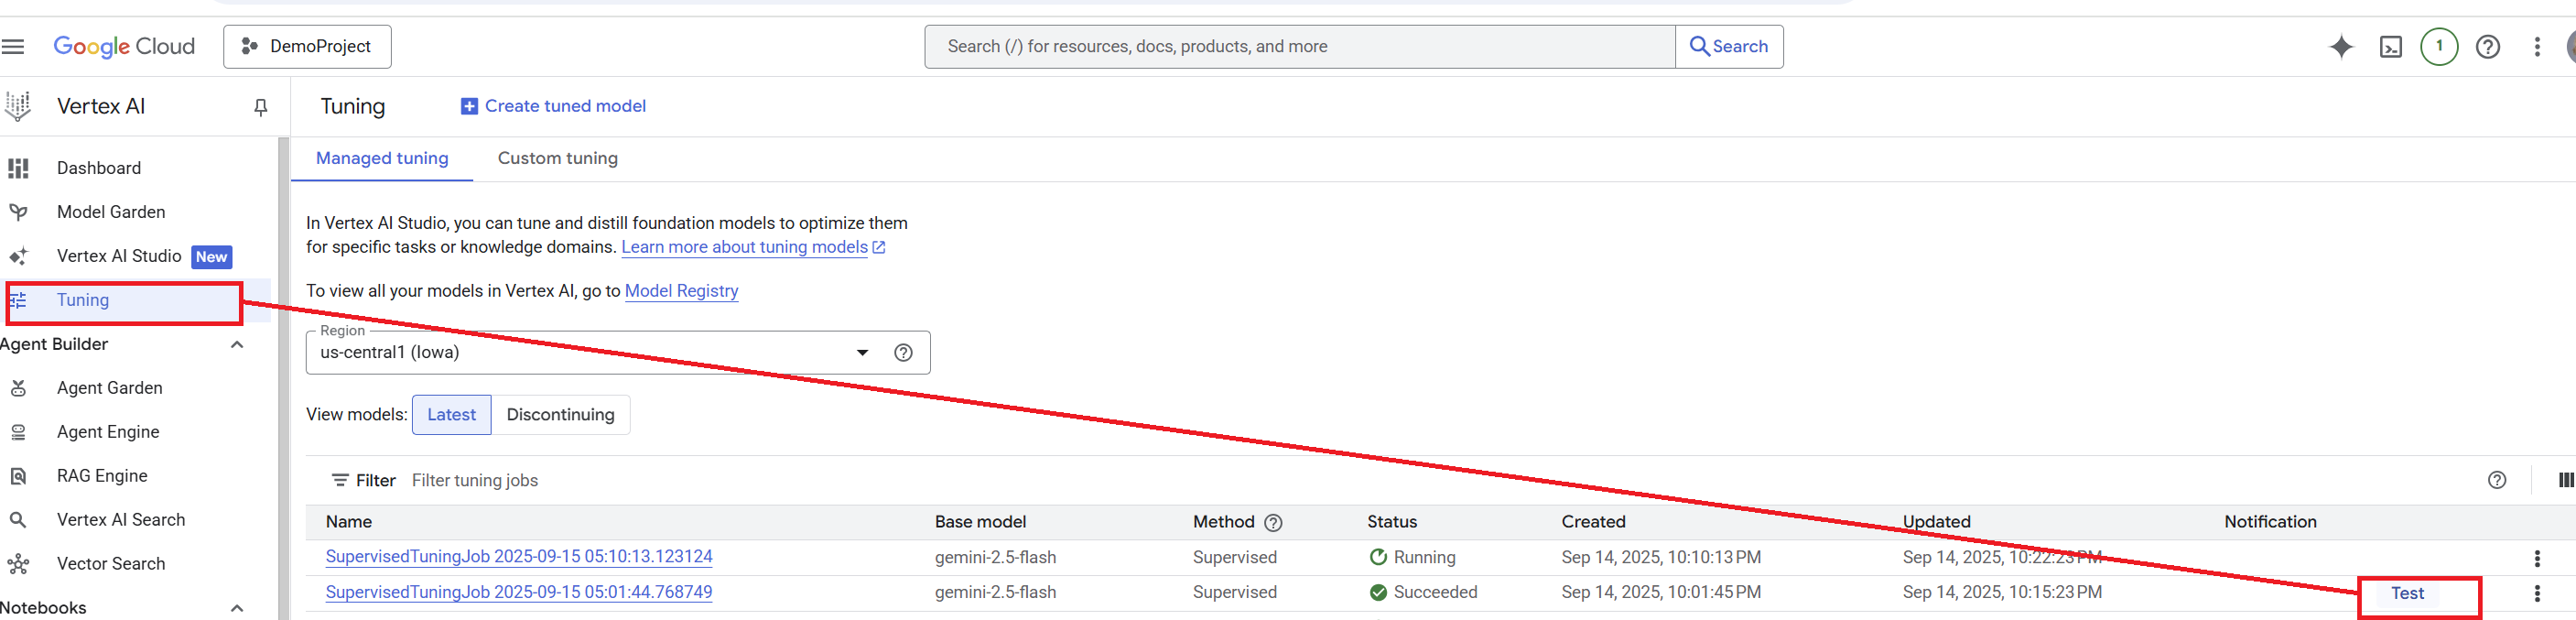

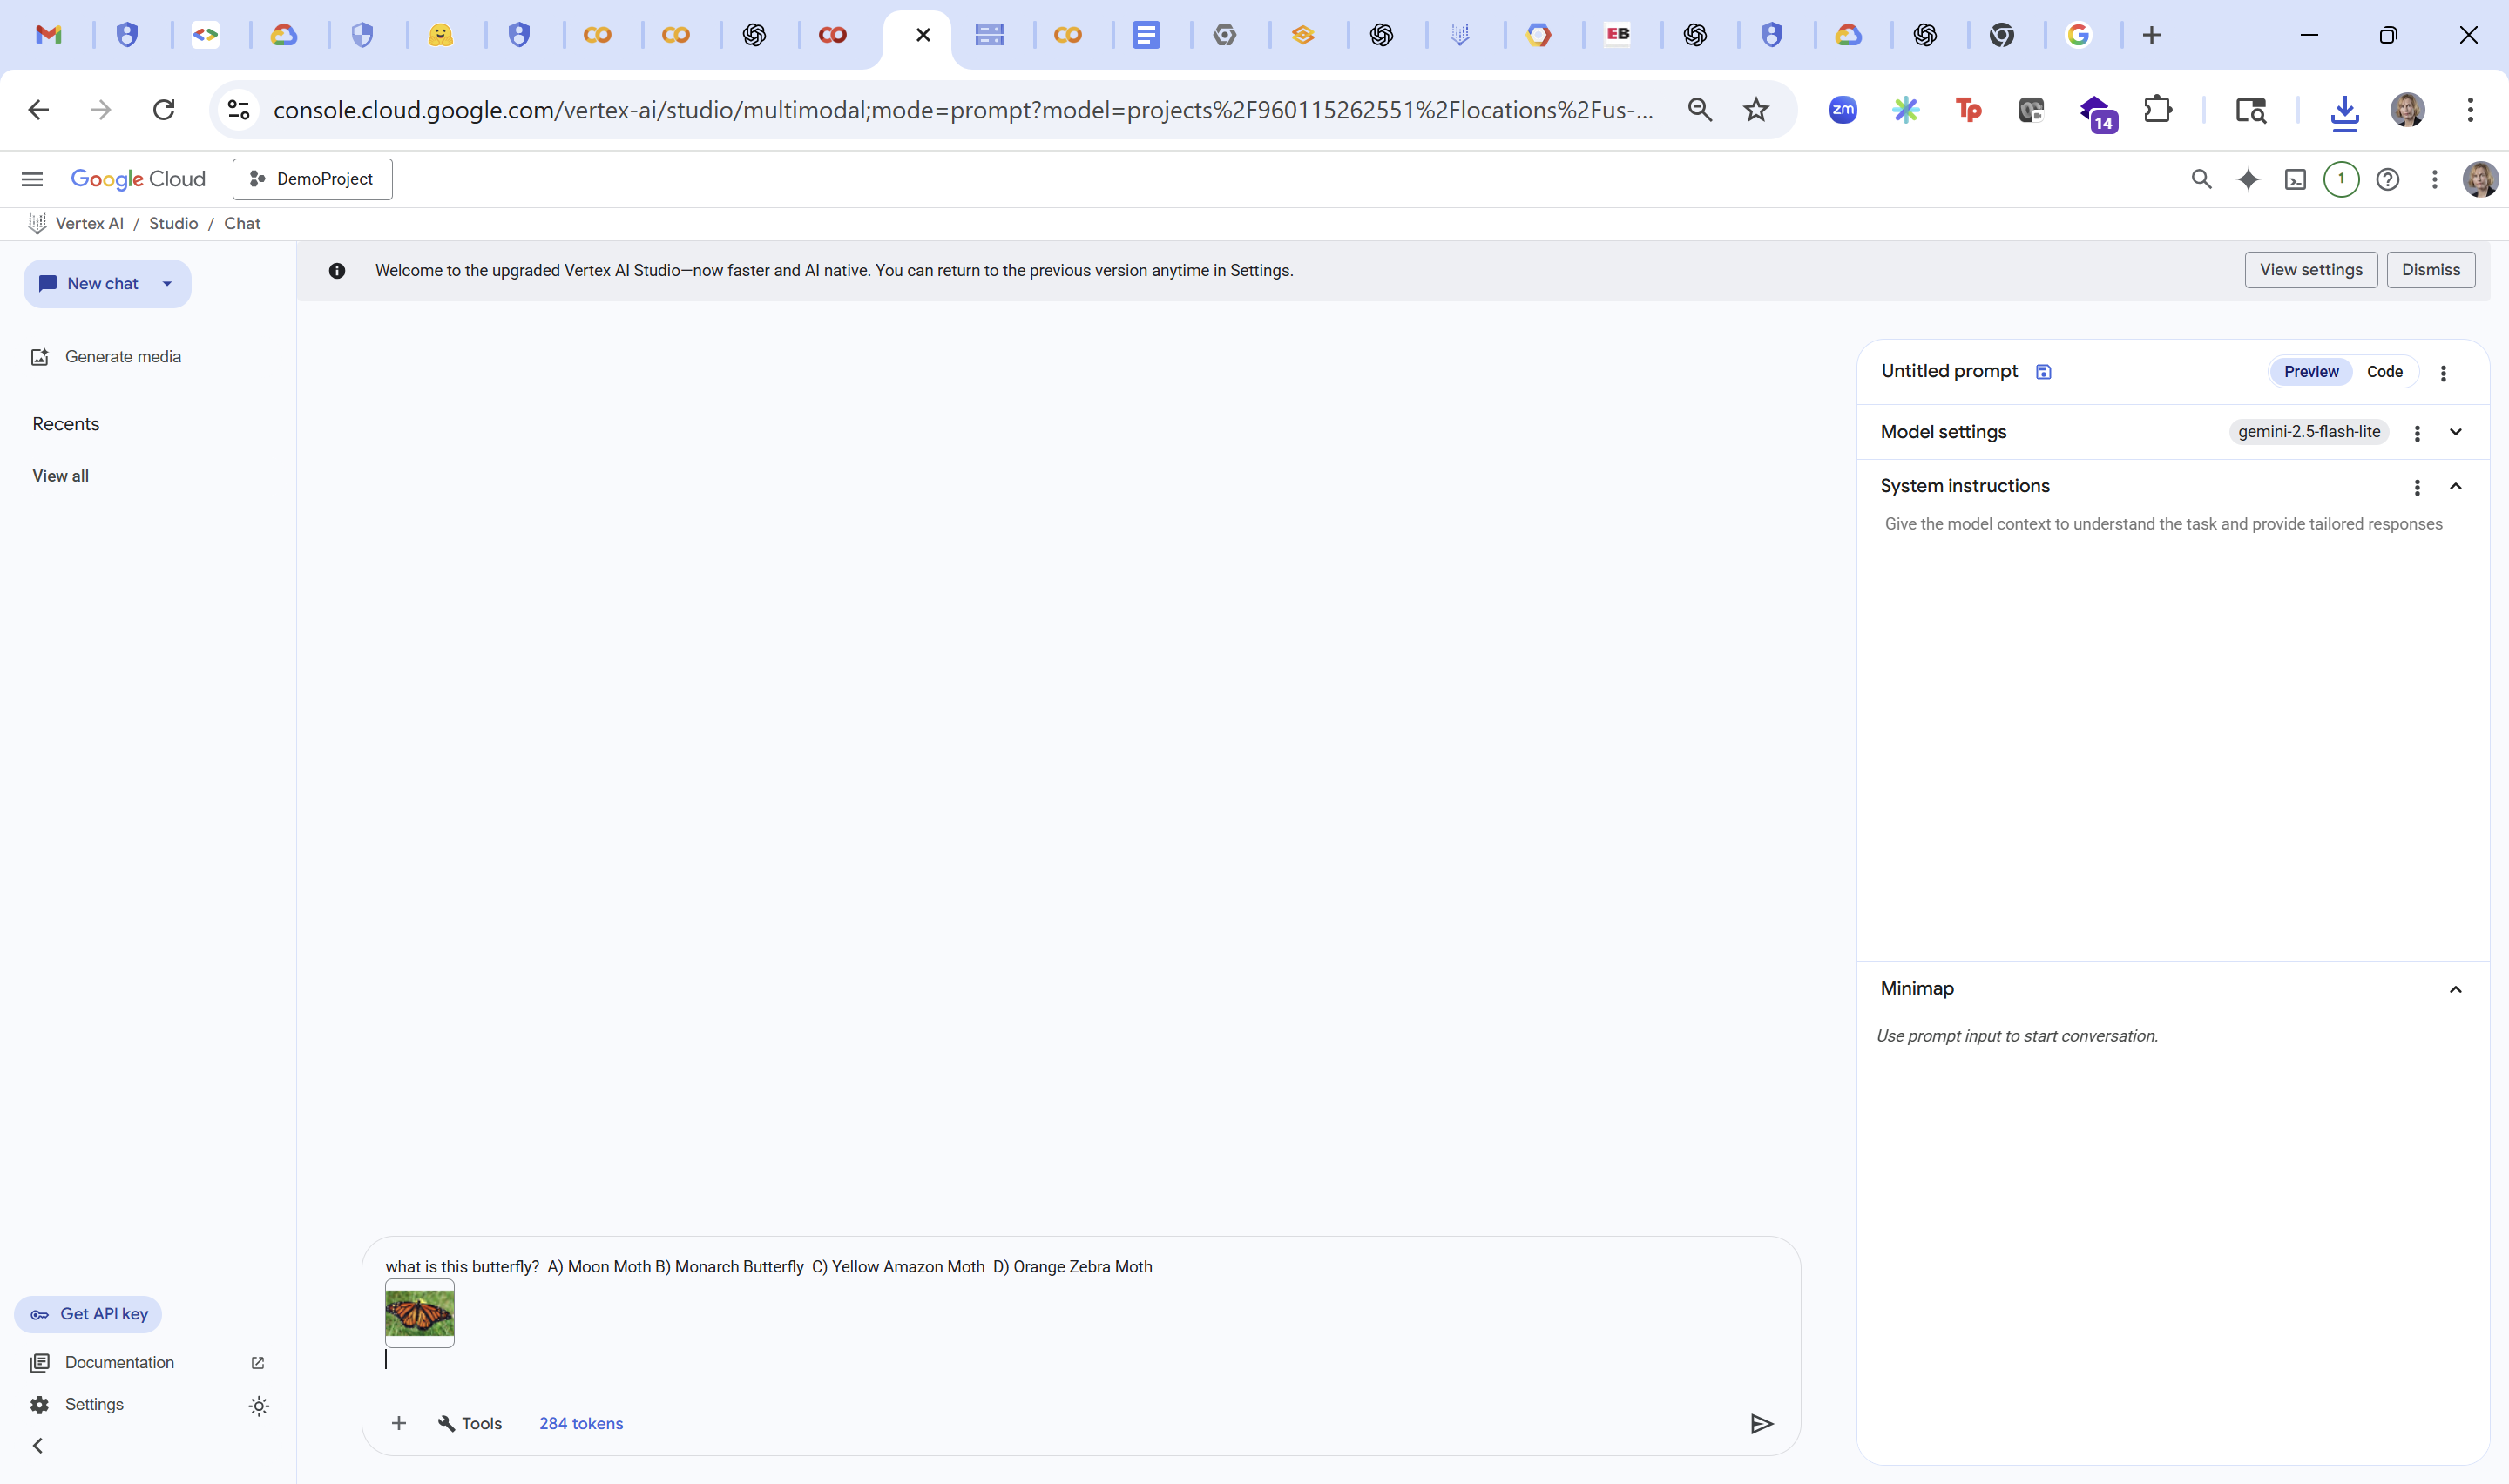

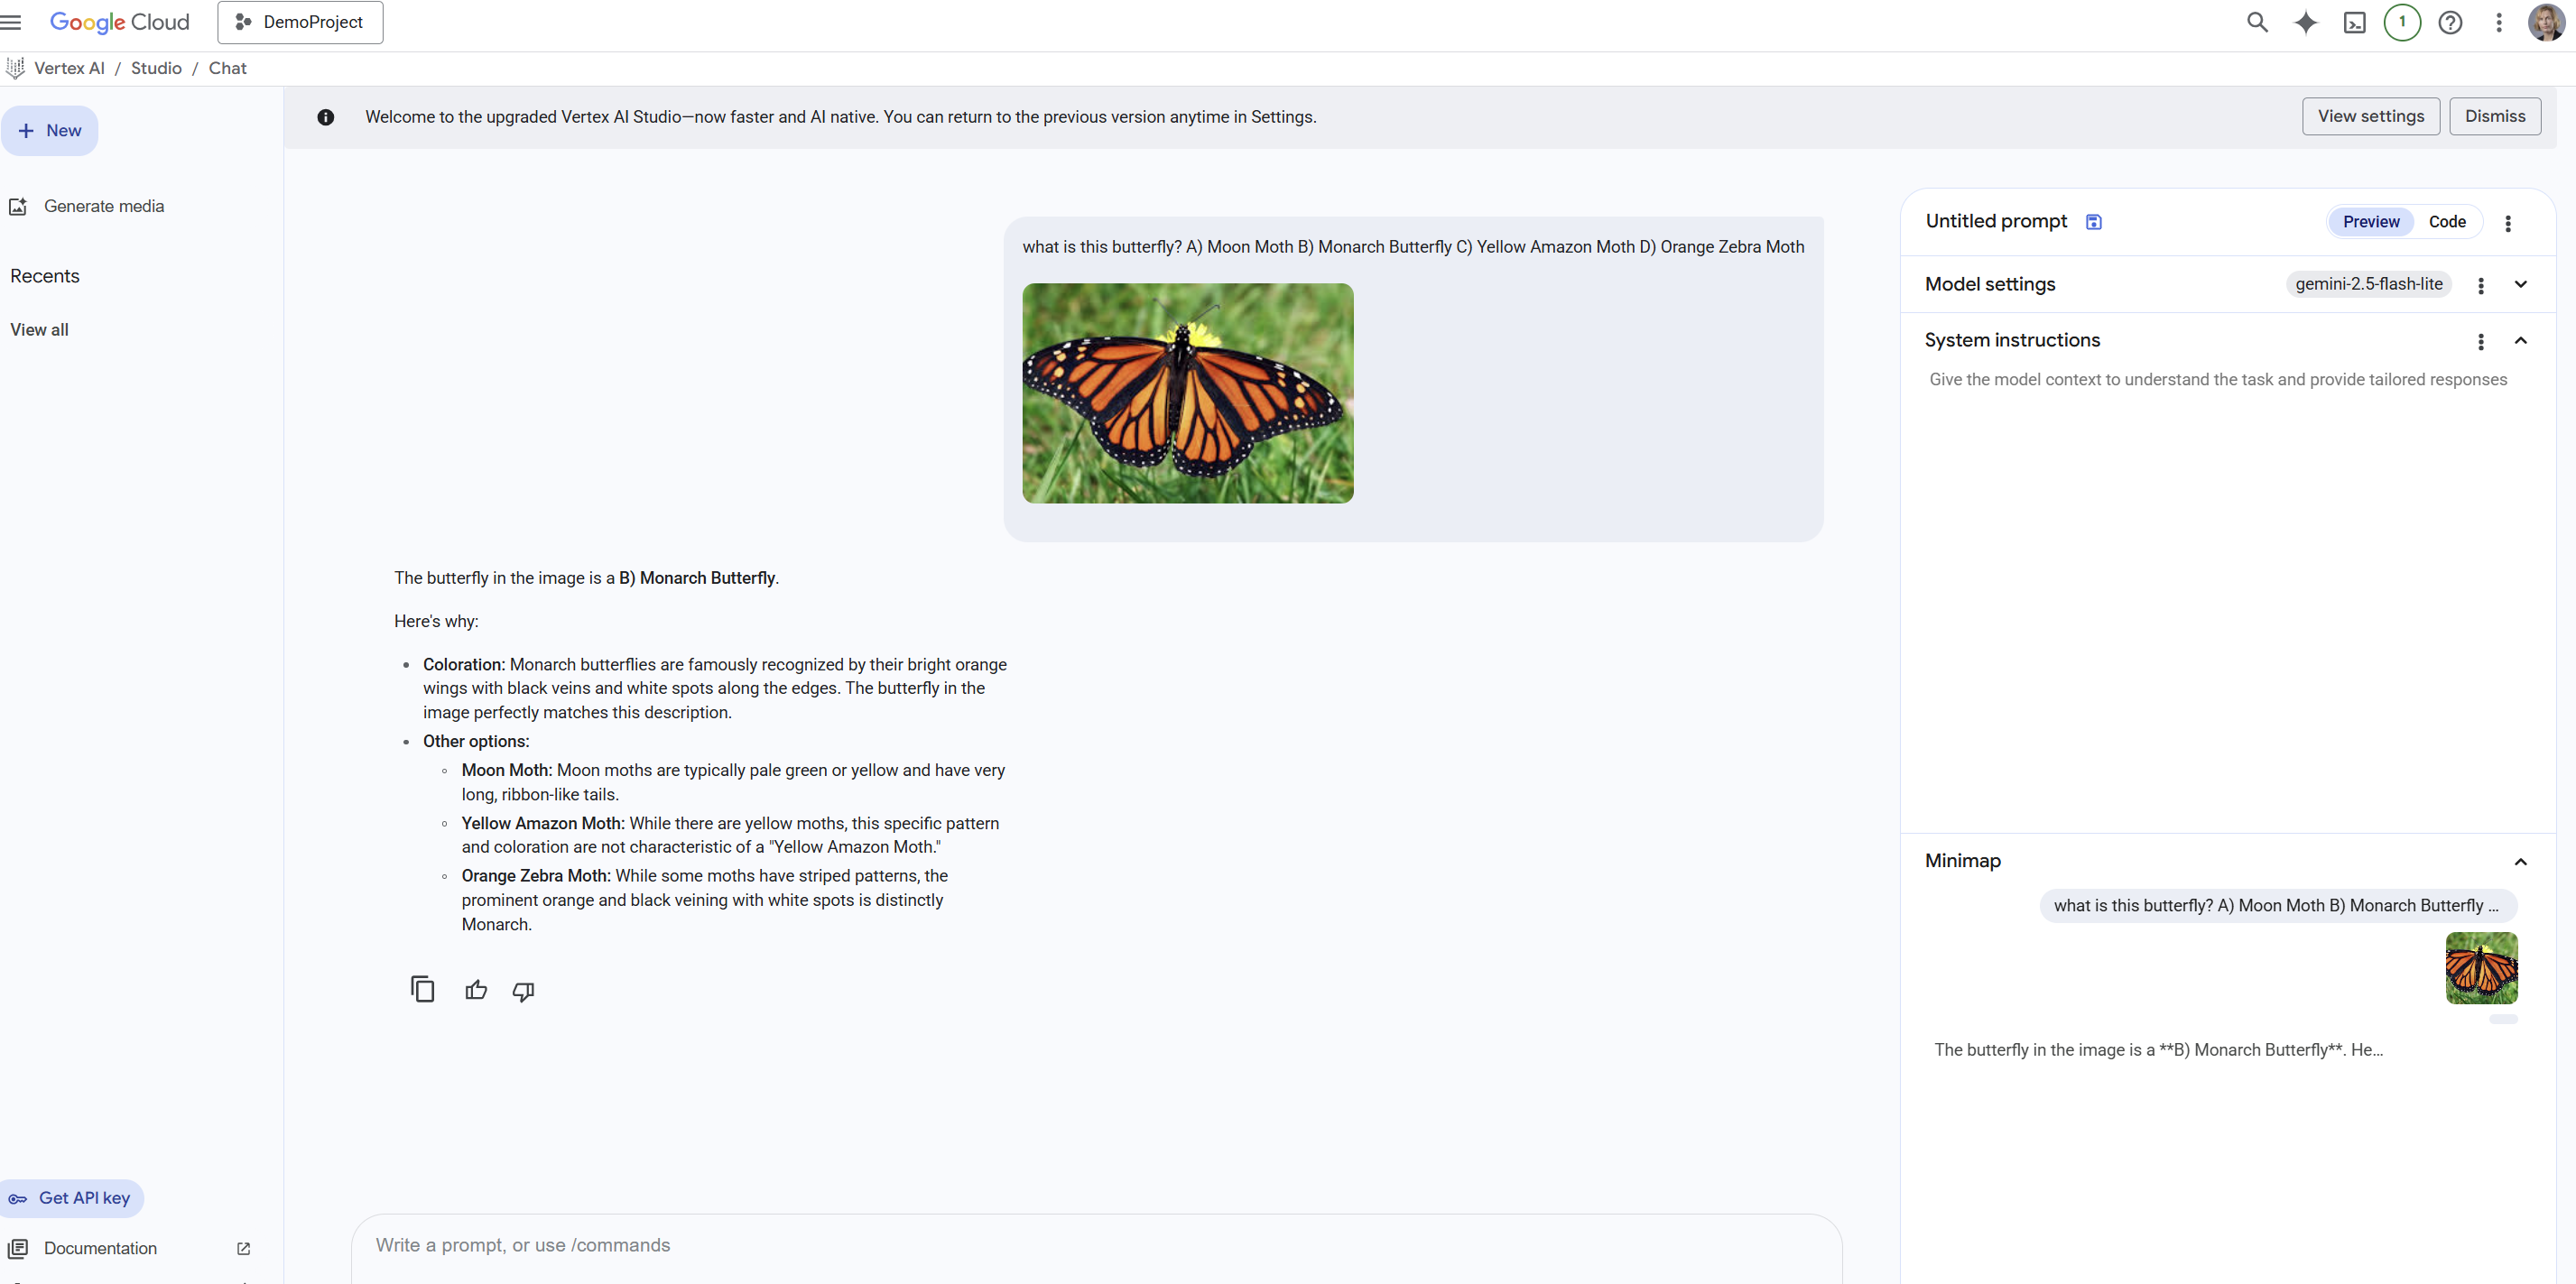

#STEP 9: Compare Fine-Tuned Model to Original Gemini

**Expected test data jsonl file format (same as train and validation)**

(currently using validation data file previously created)




```
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/0.jpg"}}, {"text": "Who wrote this book?"}]}, {"role": "model", "parts": [{"text": "Philip Marsden"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/0.jpg"}}, {"text": "What is the title of this book?"}]}, {"role": "model", "parts": [{"text": "The Bronski House: A Return to the Borderlands"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/0.jpg"}}, {"text": "What is the genre of this book?"}]}, {"role": "model", "parts": [{"text": "Travel"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/0.jpg"}}, {"text": "Is this book related to Travel?"}]}, {"role": "model", "parts": [{"text": "Yes"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/0.jpg"}}, {"text": "Is this book related to Arts & Photography?"}]}, {"role": "model", "parts": [{"text": "No"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/1.jpg"}}, {"text": "Who wrote this book?"}]}, {"role": "model", "parts": [{"text": "Maryam Mafi"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/1.jpg"}}, {"text": "What is the title of this book?"}]}, {"role": "model", "parts": [{"text": "Rumi: Hidden Music"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/1.jpg"}}, {"text": "What is the genre of this book?"}]}, {"role": "model", "parts": [{"text": "Religion & Spirituality"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/1.jpg"}}, {"text": "Is this book related to Religion & Spirituality?"}]}, {"role": "model", "parts": [{"text": "Yes"}]}]}
{"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my-gemini-sft-bucket/multimodal_sft_20250919_023834/OCR-VQA/validation/images/1.jpg"}}, {"text": "Is this book related to Self-Help?"}]}, {"role": "model", "parts": [{"text": "No"}]}]}

```



### STEP 9.1 run predictions on test data for both fine-tuned & base Gemini model

In [ ]:
# Step 9.1 A) — Evaluate tuned Gemini vs base Gemini using SFT JSONL (reads GT from file)
from typing import Any, Dict, List, Optional, Tuple
import json, os
from tqdm import tqdm
from google.genai import errors as genai_errors

# Reuse client/endpoint from STEP 8
assert 'client' in globals(), "Run STEP 8 first to create `client`."
assert 'endpoint' in globals() and endpoint, "Run STEP 8 first to resolve `endpoint`."

# ---------- Resolve a valid base Gemini model (prefer Gemini 2.5 Flash) ----------
def _probe_model_id(mid: str) -> bool:
    """Return True if this model id is available to this project/region."""
    try:
        try:
            client.models.get(mid)            # most SDKs accept positional
        except TypeError:
            client.models.get(model=mid)      # fallback signature
        return True
    except genai_errors.ClientError as e:
        # 404 => not available; 403 => not permitted; 400 => bad id format
        if getattr(e, "status_code", None) not in (404, 403, 400):
            print(f"Probe {mid} -> {getattr(e,'status_code',None)} {getattr(e,'message',e)}")
        return False

def _resolve_base_gemini(prefer_25: bool = True) -> str:
    candidates_25 = [
        "publishers/google/models/gemini-2.5-flash",
        "publishers/google/models/gemini-2.5-flash-001",
        "models/gemini-2.5-flash",
        "models/gemini-2.5-flash-001",
    ]
    candidates_15 = [
        "publishers/google/models/gemini-1.5-flash-001",
        "publishers/google/models/gemini-1.5-pro-002",
        "models/gemini-1.5-flash-001",
        "models/gemini-1.5-pro-002",
    ]
    pool = (candidates_25 if prefer_25 else []) + candidates_15
    for mid in pool:
        if _probe_model_id(mid):
            print("✅ Base model available:", mid)
            return mid
    raise RuntimeError("No base Gemini model ID worked in this project/region.")

# Respect an existing selection; else honor user BASE_MODEL; else resolve automatically
if 'BASE_MODEL_FOR_GENAI' not in globals() or not BASE_MODEL_FOR_GENAI:
    user_base = globals().get("BASE_MODEL", None)
    if user_base:
        candidate = user_base if user_base.startswith(("models/","publishers/")) else f"models/{user_base}"
        if _probe_model_id(candidate):
            BASE_MODEL_FOR_GENAI = candidate
            print("Base model    :", BASE_MODEL_FOR_GENAI)
        else:
            print(f"Provided BASE_MODEL '{candidate}' not available; resolving a valid one…")
            BASE_MODEL_FOR_GENAI = _resolve_base_gemini(prefer_25=True)
    else:
        BASE_MODEL_FOR_GENAI = _resolve_base_gemini(prefer_25=True)

print("Tuned endpoint:", endpoint)
print("Base model    :", BASE_MODEL_FOR_GENAI)

# ---------- Use the SFT validation file (contains question + ground-truth answer) ----------
test_path = "sft_validation.jsonl"  # adjust path if needed
assert os.path.exists(test_path), f"Missing {test_path}"

# ---------- Helpers ----------
def _guess_mime(uri: str) -> str:
    u = (uri or "").lower()
    if u.endswith(".png"):  return "image/png"
    if u.endswith(".webp"): return "image/webp"
    if u.endswith(".gif"):  return "image/gif"
    if u.endswith(".bmp"):  return "image/bmp"
    return "image/jpeg"

def parse_sft_record(rec: Dict[str, Any]) -> Tuple[str, Optional[str], Optional[str], str]:
    """
    Parse a Gemini SFT JSONL record like:
      {"contents":[
         {"role":"user","parts":[{"fileData":{"mimeType":"...","fileUri":"gs://..."}},{"text":"question"}]},
         {"role":"model","parts":[{"text":"answer"}]}
      ]}
    Returns: (question_text, image_uri, mime_type, ground_truth_answer)
    """
    q_text, img_uri, mime_type, gt = "", None, None, ""
    contents = rec.get("contents", [])
    for message in contents:
        role = message.get("role")
        for part in (message.get("parts") or []):
            if isinstance(part, dict):
                if role == "user" and "text" in part and not q_text:
                    q_text = str(part["text"])
                fd = part.get("fileData") or part.get("file_data")
                if role == "user" and isinstance(fd, dict):
                    img_uri   = fd.get("fileUri")  or fd.get("file_uri")  or img_uri
                    mime_type = fd.get("mimeType") or fd.get("mime_type") or mime_type
                if role == "model" and "text" in part and not gt:
                    gt = str(part["text"])
    return q_text.strip(), img_uri, mime_type, gt.strip()

def parse_messages_record(rec: Dict[str, Any]) -> Tuple[str, Optional[str], Optional[str], str]:
    # Fallback if you ever point test_path to an OpenAI-style messages file
    msgs = rec.get("messages", [])
    user_msgs = [m for m in msgs if m.get("role") == "user"]
    last = user_msgs[-1] if user_msgs else (msgs[-1] if msgs else {})
    txt = ""
    img_uri, mime_type = None, None
    content = last.get("content", [])
    if isinstance(content, dict): content = [content]
    for c in content or []:
        if c.get("type") == "text" and "text" in c:
            txt += c["text"] if isinstance(c["text"], str) else str(c["text"])
        if c.get("type") in ("input_image", "image_url", "input_image_url", "image"):
            if isinstance(c.get("image_url"), dict):
                img_uri = c["image_url"].get("url", img_uri)
            elif isinstance(c.get("image_url"), str):
                img_uri = c["image_url"]
            elif "url" in c:
                img_uri = c["url"]
    if not txt and isinstance(last.get("content"), str):
        txt = last["content"]
    mime_type = _guess_mime(img_uri) if img_uri and not mime_type else mime_type
    return txt.strip(), img_uri, mime_type, ""

def parse_record(rec: Dict[str, Any]) -> Tuple[str, Optional[str], Optional[str], str]:
    return parse_sft_record(rec) if "contents" in rec else parse_messages_record(rec)

def genai_predict(model_name: str, q_text: str, img_uri: Optional[str], mime_type: Optional[str]) -> str:
    try:
        parts = []
        if img_uri:
            parts.append({"file_data": {"file_uri": img_uri, "mime_type": mime_type or _guess_mime(img_uri)}})
        parts.append({"text": q_text or "Answer the question about the image."})
        prompt = [{"role": "user", "parts": parts}]
        resp = client.models.generate_content(model=model_name, contents=prompt)
        txt = getattr(resp, "text", None)
        if txt: return txt.strip()
        cands = getattr(resp, "candidates", []) or []
        if cands:
            content = getattr(cands[0], "content", None)
            if content and getattr(content, "parts", None):
                first = content.parts[0]
                if isinstance(first, dict) and "text" in first:
                    return str(first["text"]).strip()
        return ""
    except Exception as e:
        return f"[ERROR] {type(e).__name__}: {e}"

# ---------- Load tests ----------
test_data: List[Dict[str, Any]] = []
with open(test_path, "r", encoding="utf-8") as f:
    for line in f:
        test_data.append(json.loads(line))

# ---------- Evaluate ----------
def evaluate_model(model_name: str, out_path: str) -> int:
    results = []
    for idx, rec in tqdm(enumerate(test_data), total=len(test_data), desc=f"Eval {os.path.basename(out_path)}"):
        q_text, img_uri, mime_type, gt = parse_record(rec)
        pred = genai_predict(model_name, q_text, img_uri, mime_type)
        results.append({
            "example_id": idx,               # index in the file
            "predicted_answer": pred,
            "actual_answer": gt              # ground truth directly from file
        })
    with open(out_path, "w", encoding="utf-8") as f:
        for r in results:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
    return len(results)

ft_out   = "ocr-vqa-gemini-ft-results.jsonl"
base_out = "ocr-vqa-gemini-base-results.jsonl"

n1 = evaluate_model(endpoint, ft_out)
print(f"✓ wrote {ft_out} ({n1} rows)")
n2 = evaluate_model(BASE_MODEL_FOR_GENAI, base_out)
print(f"✓ wrote {base_out} ({n2} rows)")


Probe models/gemini-2.5-flash -> None List of found errors:	1.Field: name; Message: Invalid Model resource name.	
Provided BASE_MODEL 'models/gemini-2.5-flash' not available; resolving a valid one…
✅ Base model available: publishers/google/models/gemini-2.5-flash
Tuned endpoint: projects/960115262551/locations/us-central1/endpoints/4871728214977806336
Base model    : publishers/google/models/gemini-2.5-flash


Eval ocr-vqa-gemini-ft-results.jsonl: 100%|██████████| 10/10 [01:25<00:00,  8.58s/it]


✓ wrote ocr-vqa-gemini-ft-results.jsonl (10 rows)


Eval ocr-vqa-gemini-base-results.jsonl: 100%|██████████| 10/10 [01:28<00:00,  8.82s/it]

✓ wrote ocr-vqa-gemini-base-results.jsonl (10 rows)


Question: What is the name of the species in this image? Options: A) PURPLE HAIRSTREAK B) CABBAGE WHITE C) COMMON WOOD-NYMPH D) JULIA
Image URI: gs://my-gemini-sft-bucket_lynne_grewe/multimodal_sft_20250927_201331/butterflies_and_moths_vqa/train/images/0.jpg
Ground truth: A
Tuned prediction: The butterfly in the image is predominantly a brilliant, iridescent blue on its upperside, with black borders. It also features small dark spots on its forewings.

Let's evaluate the given options:

*   **A) PURPLE HAIRSTREAK (Favonius quercus):** Males of the Purple Hairstreak are known for their striking iridescent purplish-blue uppersides, which can often appear very blue depending on the lighting and angle. They have dark wing margins and sometimes have small dark spots on the forewings. The butterfly in the image strongly matches this description, especially the vibrant blue iridescence.
*   **B) CABBAGE WHITE (Pieris rapae):** These butterflies are typically white with black tips on their for

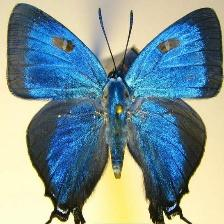

In [ ]:
# Step 9.1 B) — Preview first eval sample (image + Q/A + predictions)

import os, json, io
from IPython.display import display
from PIL import Image as PILImage

# Paths from Step 9.1 (change if you renamed them)
test_path = "sft_validation.jsonl"
ft_out    = "ocr-vqa-gemini-ft-results.jsonl"
base_out  = "ocr-vqa-gemini-base-results.jsonl"

def _guess_mime(uri: str) -> str:
    u = (uri or "").lower()
    if u.endswith(".png"):  return "image/png"
    if u.endswith(".webp"): return "image/webp"
    if u.endswith(".gif"):  return "image/gif"
    if u.endswith(".bmp"):  return "image/bmp"
    return "image/jpeg"

def _parse_first_sft(path: str):
    """Return (question, image_uri, mime_type, ground_truth) for the first record."""
    with open(path, "r", encoding="utf-8") as f:
        line = f.readline()
    rec = json.loads(line)

    q_text, img_uri, mime_type, gt = "", None, None, ""
    contents = rec.get("contents", [])
    for message in contents:
        role = message.get("role")
        for part in (message.get("parts") or []):
            if isinstance(part, dict):
                if role == "user" and "text" in part and not q_text:
                    q_text = str(part["text"])
                fd = part.get("fileData") or part.get("file_data")
                if role == "user" and isinstance(fd, dict) and not img_uri:
                    img_uri   = fd.get("fileUri")  or fd.get("file_uri")
                    mime_type = fd.get("mimeType") or fd.get("mime_type")
                if role == "model" and "text" in part and not gt:
                    gt = str(part["text"])
    if img_uri and not mime_type:
        mime_type = _guess_mime(img_uri)
    return q_text.strip(), img_uri, mime_type, gt.strip()

def _load_prediction(jsonl_path: str, idx: int = 0):
    """Read 'predicted_answer' for row idx from a JSONL results file."""
    if not os.path.exists(jsonl_path):
        return None
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i == idx:
                try:
                    return json.loads(line).get("predicted_answer", "")
                except Exception:
                    return ""
    return None

def _fetch_image(uri: str):
    """Return a PIL Image from gs://, http(s)://, or local path."""
    if not uri:
        return None
    if uri.startswith("gs://"):
        from google.cloud import storage
        bucket_name, blob_name = uri[5:].split("/", 1)
        tmp_path = f"/tmp/_preview_{os.path.basename(blob_name)}"
        storage.Client().bucket(bucket_name).blob(blob_name).download_to_filename(tmp_path)
        return PILImage.open(tmp_path)
    if uri.startswith("http"):
        import requests
        resp = requests.get(uri, timeout=30)
        resp.raise_for_status()
        return PILImage.open(io.BytesIO(resp.content))
    # assume local file path
    return PILImage.open(uri)

# --- Grab the first sample ---
q_text, img_uri, mime_type, gt = _parse_first_sft(test_path)
tuned_pred = _load_prediction(ft_out, 0)
base_pred  = _load_prediction(base_out, 0)

print("Question:", q_text or "(none)")
print("Image URI:", img_uri or "(none)")
print("Ground truth:", gt or "(none)")
if tuned_pred is not None:
    print("Tuned prediction:", tuned_pred)
if base_pred is not None:
    print("Base prediction :", base_pred)

img = _fetch_image(img_uri) if img_uri else None
if img:
    display(img)
else:
    print("(No image available to display)")


### STEP 9.2 Display results in table - side by side

example on Book Cover dataset

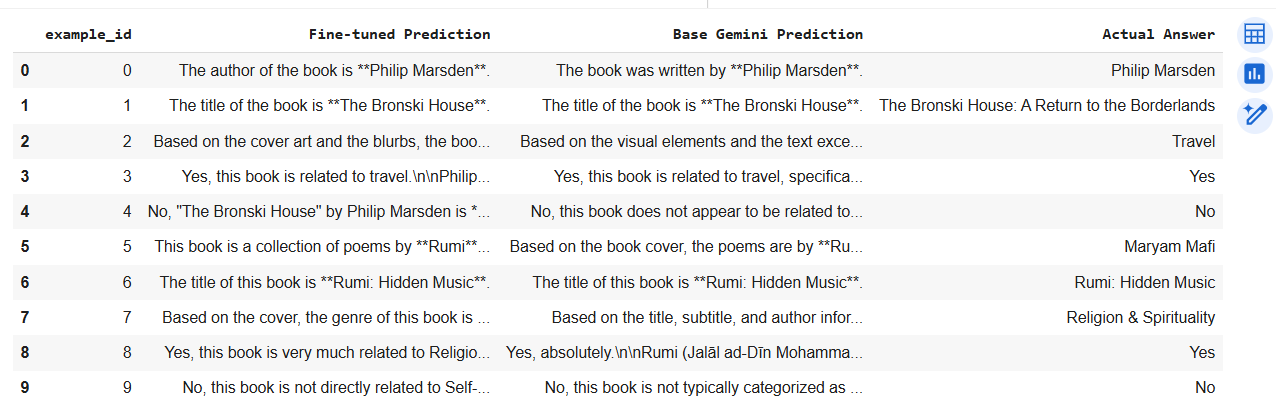

extended view of PART of table for Radiology dataset

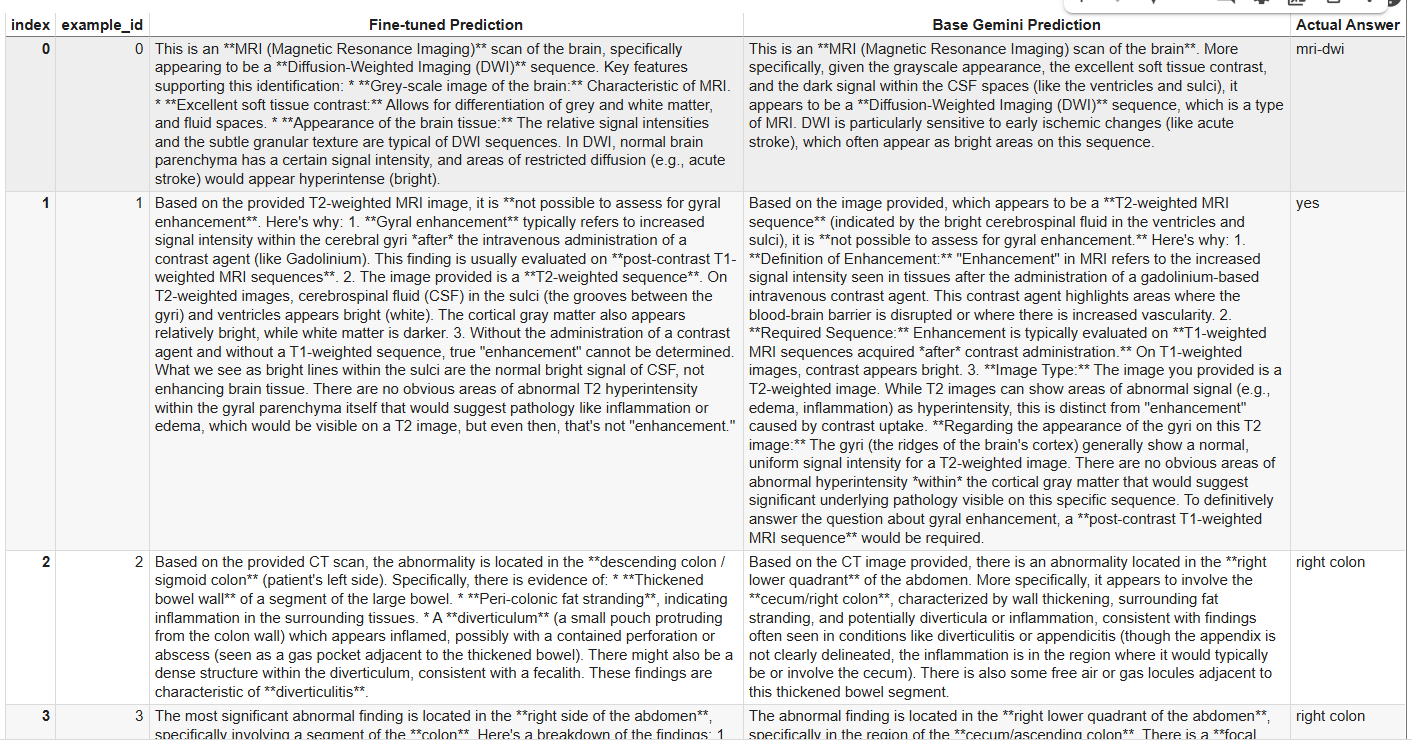

Example results for Gastrointestinal data set

first sample is

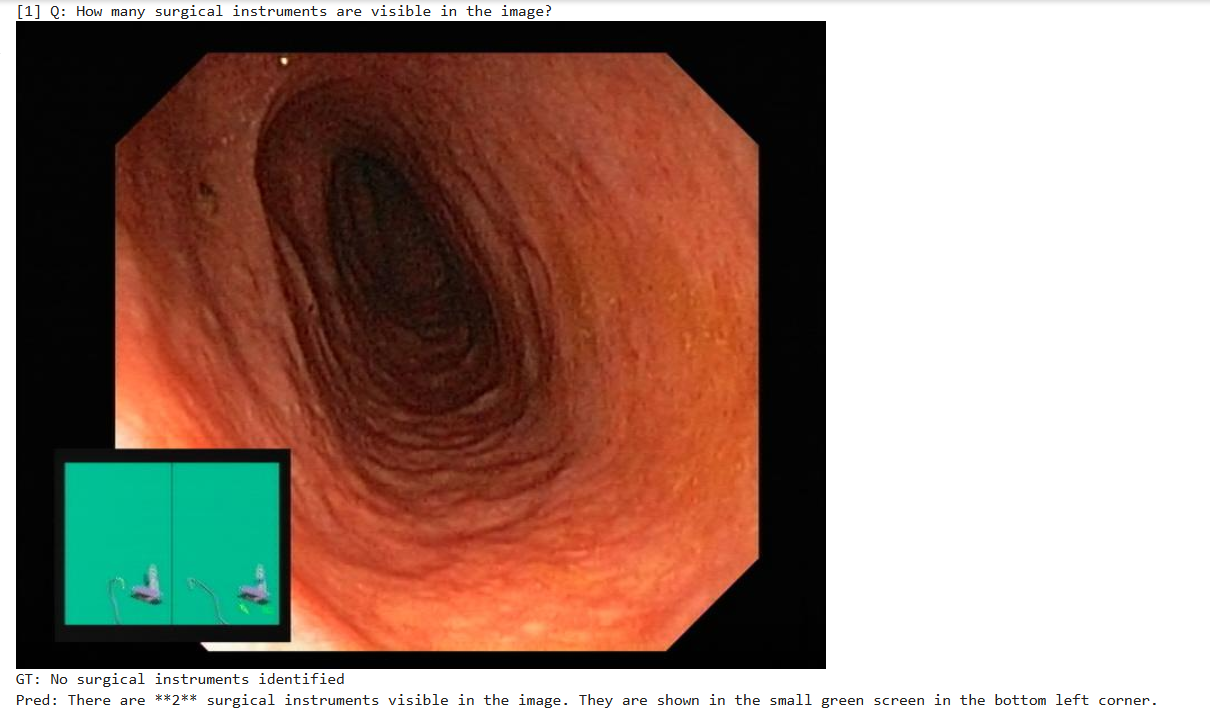

partial tableExample BOOK COVERS---

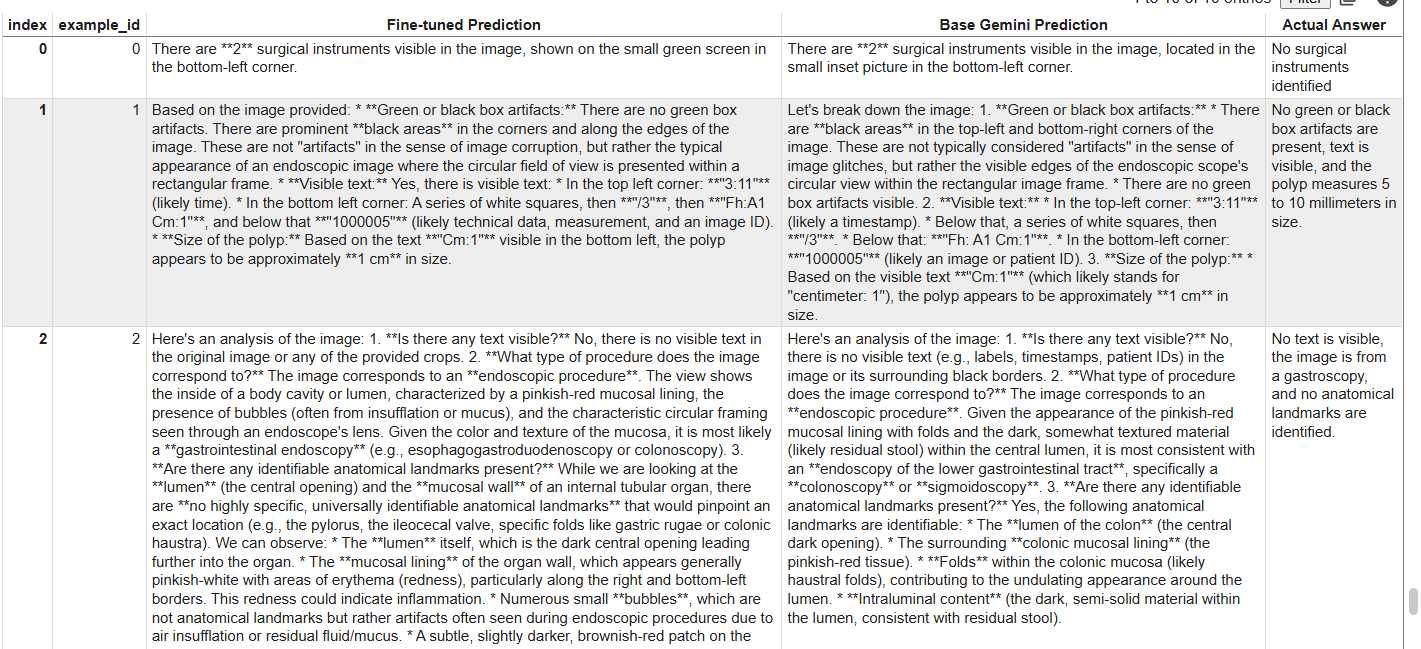

partial table --EXAMPLE butterflies

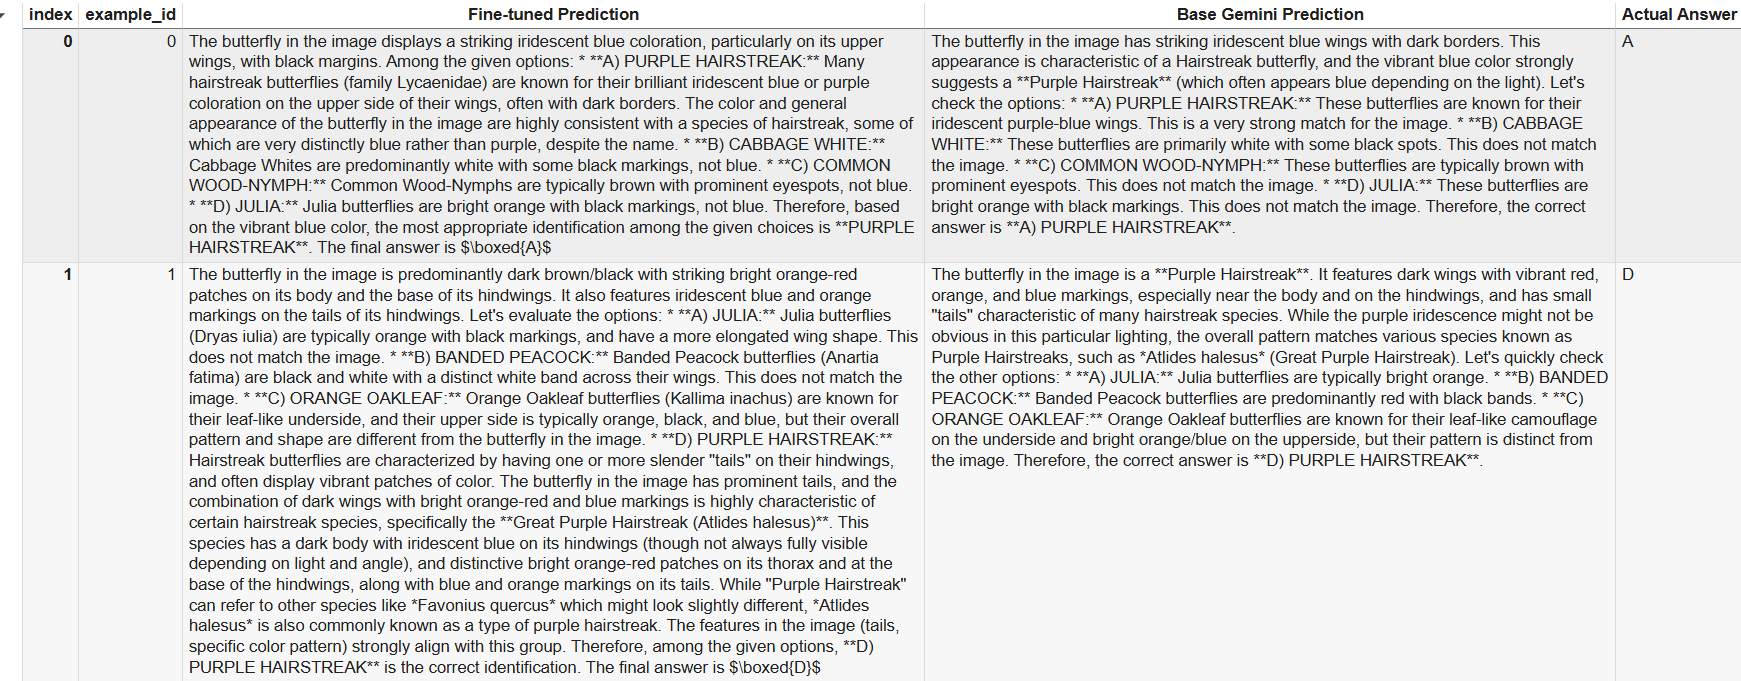

Where first test sample is:

Question: What is the name of the species in this image? Options: A) PURPLE HAIRSTREAK B) CABBAGE WHITE C) COMMON WOOD-NYMPH D) JULIA

Ground truth: A


* Tuned prediction:******* The final answer is $\boxed{A}$
* Base prediction : ****** Therefore, the correct answer is A) PURPLE HAIRSTREAK.

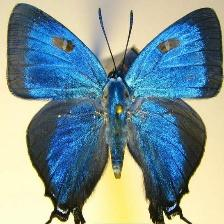

In [ ]:
# STEP 9.2 — Compare tuned-vs-base predictions on the first 10 examples
import pandas as pd
import json

ft_out   = "ocr-vqa-gemini-ft-results.jsonl"
base_out = "ocr-vqa-gemini-base-results.jsonl"

# Load results
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

ft_rows   = load_jsonl(ft_out)
base_rows = load_jsonl(base_out)

ft_df   = pd.DataFrame(ft_rows)
base_df = pd.DataFrame(base_rows)

# Merge on example_id to align predictions
merged = pd.merge(ft_df, base_df, on="example_id", suffixes=("_ft", "_base"))

# Select top 10 to preview
top10 = merged.head(10)[[
    "example_id",
    "predicted_answer_ft",
    "predicted_answer_base",
    "actual_answer_ft"    # same ground truth; pulled from ft file
]].rename(columns={
    "predicted_answer_ft":   "Fine-tuned Prediction",
    "predicted_answer_base": "Base Gemini Prediction",
    "actual_answer_ft":      "Actual Answer"
})

from IPython.display import display
display(top10)


,example_id,Fine-tuned Prediction,Base Gemini Prediction,Actual Answer
0,0,The butterfly in the image is predominantly a ...,The butterfly in the image has striking irides...,A
1,1,The butterfly in the image is a **Hairstreak**...,The butterfly in the image is a **Purple Hairs...,D
2,2,The butterfly pictured is very likely a **Band...,The butterfly shown is a **Brown Hairstreak** ...,B
3,3,The butterfly in the image is a species of **e...,"The butterfly in the image is a type of ""Azure...",A
4,4,"The butterfly in the image is a small, delicat...","The butterfly in the image is a small, delicat...",B
5,5,The butterfly in the image has a distinctive p...,The butterfly in the image has a distinctive p...,C
6,6,The butterfly in the image is a type of **Azur...,"Based on the appearance of this butterfly, it ...",A
7,7,The butterfly in the image is a **Small Copper...,The butterfly in the image is a **Small Copper...,A
8,8,The butterfly in the image has pale yellow to ...,The butterfly in the image is a **Clouded Sulp...,B
9,9,The butterfly in the image is predominantly ye...,The butterfly in the image is predominantly ye...,D


#DISCUSSION ADVANCED CONCEPTS: Evaluation Metrics/ Ideas for Fine-Tuned Model (text output)

<font color=green>we do not have time to discuss or perform text-text similarity metrics for model comparison/evaluation --but, here are some rough ideas you can read about.</font>

<font color=blue>***comparing fine-tuned and base model-  ideas with pseudo code***</font>



**Translation Evaluation:** ΔBLEU/chrF < ~+1 point, or humans don’t prefer tuned > ~55% of the time.  There are numerous "similarity" metrics for text (our models output) BLEU is one option.
```
!pip -q install evaluate sacrebleu

# Your code should fill these lists 1:1 with refs
refs = []         # truth answers (strings)
base_preds = []   # base model outputs
tuned_preds = []  # fine-tuned model outputs

#STEP 1: get truth, fine-tuned and base output on test samples
for ex in eval_examples:  # each has ex.image_uri, ex.question, ex.reference
    refs.append(ex.reference)

    base_out  = call_base_model(image_uri=ex.image_uri, text=ex.question)   # -> "red"
    tuned_out = call_tuned_model(image_uri=ex.image_uri, text=ex.question)  # -> "rojo"/"red"/etc.

    base_preds.append(base_out)
    tuned_preds.append(tuned_out)


#STEP 2: Calculate blue metrics
import evaluate
bleu = evaluate.load("sacrebleu")
refs_wrapped = [[r] for r in refs_norm]

base_bleu  = bleu.compute(predictions=base_preds,  references=refs_wrapped, smooth_method="exp")
tuned_bleu = bleu.compute(predictions=tuned_preds, references=refs_wrapped, smooth_method="exp")

print("BASE  BLEU:",  round(base_bleu["score"], 2))
print("TUNED BLEU:",  round(tuned_bleu["score"], 2))
print("Δ BLEU:",round(tuned_bleu["score"] - base_bleu["score"], 2))
```

**VQA Exact Match Accuracy:** ΔAccuracy < ~+2–3 points *(negligible gain).*

This is a nieve approach not often used.  It compares word by word if their is a match to the truth text for the base and the fine-tuned model generated/predicted text.  
* <font color=red>Use only on output text that is smaller and possible constrained in the truth answers of our VQA data or where use of certain words like Benign, Stage 3 are important.</font>
```
base_acc  = sum(norm(p)==norm(r) for p,r in zip(base_preds, refs))/len(refs)
tuned_acc = sum(norm(p)==norm(r) for p,r in zip(tuned_preds, refs))/len(refs)


```

**Underfitting patterns**

* Answers are generic, short, ignore image details (colors/numbers/text in image), or repeat safe phrases.

**Curve Trends**
* Training loss barely drops; longer training or higher LR doesn’t help, but a bigger adapter might help.

<br><br>

<hr>

### **Quick, low-cost test plan & alteration of adapter size**

1. Fix a small dev set (100–300 examples) with truth (gold answers).

2. Score the base model → record metrics.

3. Tune with adapter=1 → re-score on the same dev.

4. If model performs poorly using metrics/observations above bump adapter size to 4, then 8.
